# Predicting Listing Prices for Airbnb NYC, Exploring of Different Predictive Models

## Part III: Modelling
  - 3.1. Train-Test Split and Data Standardisation
  - 3.2. Predictive Models
    - 3.2.1. Ridge Regression
    - 3.2.2. Random Forest Regression
    - 3.3.3. XGBoost Regression
- 3.2.4.MLP Regression 1 with Scikit Learn
- 3.2.5. MLP Regression 2 with Scikit Learn - increasing # hidden_layers
- 3.2.6.MLP_Regression_3: Changing Optimiser(SGD)
- 3.2.7.MLP_Model_4(Scikit-Learn),decreased learning rate
- 4.2.8.MLP_Model_5(Keras)
- 3.2.9. MLP_Model_6_Keras: MAE loss
- 3.2.10.MLP_MODEL 7:Changing Activation
- Function(->Elu)
- 3.2.11.MLP_Model_8(Keras): Radical Hyparameter Change
  - 3.3. Shortlisting the Best Predictive Models

#### Importing Libraries

In [6]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
matplotlib.style.use('seaborn-v0_8')
from mpl_toolkits import mplot3d
import matplotlib.cm as cm

#showing all outputs in a cell 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from sklearn.model_selection import train_test_split, cross_val_score

#for feature standardisation
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import time

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

from sklearn.model_selection import cross_val_score

from keras.models import Sequential
from keras.layers import Dropout
from plotly.subplots import make_subplots
import plotly.graph_objs as go
# !pip install tensorflow
 
import tensorflow as tf
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
# setting the device placement to GPU-only
 #to ensure that Tf runs on  GPU instead of attempting to utilise a GPU
tf.config.set_visible_devices([], 'GPU')
from tensorflow import keras
from keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers

# 3. Exploration of Predictive Models

## 3.1. Train-Test Split & Data Standardisation

Upon exploring predictive models, most basic hyperparameters were selected to establish baseline performance. To avoid data leakage, variables were standardised after the split (Mahesh, 2020).

In [11]:
df_merged = pd.read_csv('Airbnb_ml_project/data/processed/airbnb_part_2.csv')

In [12]:
#Splitting the data into predictor variables and target variable
X = df_merged.drop('price_dollars', axis = 1).values
y = df_merged.price_dollars.values
#Splitting the Data into the Training and Test Sets
#** X_train2 and y_train2 will be utilised in teh iteration(2) when fine-tuning th
X_train2, X_test, y_train2, y_test = train_test_split(X, y,
                                                      test_size=0.2, random_state=25)
#Splitting the Training set into 80% Training and 20% Validation
X_train, X_val, y_train, y_val = train_test_split(X_train2, y_train2, 
                                                  train_size=0.8, random_state=25)

In [13]:
#scaling features on training, validation and test data
#to ensure all variables are on a similar scale 
#and to reduce models' bias towards certain features
#and, thus, impove models' performance
#Applying the StandardScaler to reshape the features to have properties of the Sta
#Normal Distribution (mean=0, standard Deviation = 1)
#(substracting the feature's mean from each data point and dividing it by its SD)
#creating a standard scaler object
scaler = StandardScaler()
#Performing Scaling on Training Set
#fitting the scaler object to the training data and then transforming it 
X_train_std = scaler.fit_transform(X_train)
#Performing Scaling on Validation Set
#transforming the validation data
X_val_std = scaler.transform(X_val)
#Performing Scaling on Test Set
#transforming the test data
X_test_std = scaler.transform(X_test)
#similarly, standardising the highly-skewed target variable
#since standard scaler expects 2D arrays an input (1st Dim - #samples, 
#2nd Dim - #features), reshaping the target variable from a 1D array
#(1 feature) to a 2D arr with 1 column
y_train_std = scaler.fit_transform(y_train.reshape((-1,1)))
y_val_std = scaler.transform(y_val.reshape((-1,1)))
y_test_std = scaler.transform(y_test.reshape((-1,1)))

In [18]:
np.save('Airbnb_ml_project/data/arrays/X_train_std.npy', X_train_std)
np.save('Airbnb_ml_project/data/arrays/X_val_std.npy', X_val_std)
np.save('Airbnb_ml_project/data/arrays/X_test_std.npy', X_test_std)
np.save('Airbnb_ml_project/data/arrays/y_train_std.npy', y_train_std)
np.save('Airbnb_ml_project/data/arrays/y_val_std.npy', y_val_std)
np.save('Airbnb_ml_project/data/arrays/y_test_std.npy', y_test_std)
np.save('Airbnb_ml_project/data/arrays/X_train2.npy', X_train2)
np.save('Airbnb_ml_project/data/arrays/X_test.npy', X_test)   # unscaled, used by tree models (RF, XGB)
np.save('Airbnb_ml_project/data/arrays/y_test.npy', y_test)
np.save('Airbnb_ml_project/data/arrays/y_train2.npy', y_train2)

## 3.2.Predictive Models

### 3.2.1.Ridge Regression (L2 Regularisation)

In [19]:
#starting with the most simple ML algorithm 
#Ridge - linear regression with L2 Regularisation
#prevents overfitting via shrinking less important 
#coefficients to 0 -> resulting in a simpler model 
#eith lower likelihood of fitting noise to training data
# Creating a Ridge regression object
#setting alpha/lambda/L2 to 1 for the regularisatino to
#have a moderate influence on the model
#(commonly-selected default value), providing balance 
#between bias & variance
Ridge_model_1 = Ridge(alpha=1.0)
# Timing the training process
start_time_Ridge_1 = time.time()
# Fitting the model on the whole training data and 
#obtaining the coefficients
Ridge_model_1.fit(X_train_std, y_train_std)
end_time_Ridge_1= time.time()
# Displaying the coefficients of the Ridge Regression Model
pd.DataFrame(Ridge_model_1.coef_.flatten(),
             df_merged.drop('price_dollars', axis = 1).columns,
             columns = ['Coefficient']).sort_values(by = 'Coefficient',
                                            ascending = False).round(4)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

,Coefficient
Entire home/apt,0.2758
Days_per_year_available,0.1667
Unnamed: 0,0.0948
Manhattan,0.0788
total_host_listings,0.0240
Queens,0.0203
Prime_Stuite_with_large_bed_and_floor,0.0036
New_apt_with_view,0.0020
Piece_and_Quiet,0.0015
Perfect_Location,0.0008


In [11]:
# Calculating the time taken for training
training_time_Ridge_1 = end_time_Ridge_1 - start_time_Ridge_1
print(f'Training time of Ridge Model 1: {training_time_Ridge_1:.4f} seconds')

Training time of Ridge Model 1: 0.0339 seconds


In [12]:
# NOTE (recovered from PDF): this cell may be missing characters that were clipped off the right edge of the original PDF export -- please check/fix before running.
# Evaluating the Ridge Regression Model's performance on the training set 
# Computing the predicted values on the train set
y_pred_train_Ridge_1 = Ridge_model_1.predict(X_train_std)
# Computing the R2, MSE and MAE on the train set using these predicted values
R2_Ridge_1_train = r2_score(y_train_std, y_pred_train_Ridge_1)
MSE_Ridge_1_train = mean_squared_error(y_train_std, y_pred_train_Ridge_1)
MAE_Ridge_1_train = mean_absolute_error(y_train_std, y_pred_train_Ridge_1)
# Printing the evaluation metrics on the train set
print(f'The R-squared of the Ridge Regression 1 on the train set: {R2_Ridge_1_train * 100:.2f}%')
print(f'The MSE of the Ridge Regression 1 on the train set: {MSE_Ridge_1_train:.2f}')
print(f'The MAE of the Ridge Regression 1 on the train set: {MAE_Ridge_1_train:.2f}')

The R-squared of the Ridge Regression 1 on the train set: 46.27%
The MSE of the Ridge Regression 1 on the train set: 0.54
The MAE of the Ridge Regression 1 on the train set: 0.53


In [13]:
# Predicting the target values on the  validation data using the trained model
y_pred_val_Ridge_1 = Ridge_model_1.predict(X_val_std)
# Evaluating the model performance on the validation data using the R2, MSE and MAE
R2_Ridge_1_val = r2_score(y_val_std, y_pred_val_Ridge_1)
MSE_Ridge_1_val = mean_squared_error(y_val_std, y_pred_val_Ridge_1)
MAE_Ridge_1_val = mean_absolute_error(y_val_std, y_pred_val_Ridge_1)
# Printing the evaluation metrics on the validation set
print(f'The R-squared of the Ridge Regression 1 on the validation set: {R2_Ridge_1_val * 100:.2f}%')
print(f'The MSE of the Ridge Regression 1 on the validation set: {MSE_Ridge_1_val:.2f}')
print(f'The MAE of the Ridge Regression 1 on the validation set is: {MAE_Ridge_1_val:.2f}')

The R-squared of the Ridge Regression 1 on the validation set: 46.49%
The MSE of the Ridge Regression 1 on the validation set: 0.53
The MAE of the Ridge Regression 1 on the validation set is: 0.53


In [14]:
# NOTE (recovered from PDF): this cell may be missing characters that were clipped off the right edge of the original PDF export -- please check/fix before running.
# # Evaluating the Ridge Regression Model's performance on the test set 
# Calculating the predicted values 
y_pred_test_Ridge_1= Ridge_model_1.predict(X_test_std)
# Computing the R2, MSE and MAE on the test set using these predicted values
R2_Ridge_1_test = r2_score(y_test_std, y_pred_test_Ridge_1)
MSE_Ridge_1_test = mean_squared_error(y_test_std, y_pred_test_Ridge_1)
MAE_Ridge_1_test = mean_absolute_error(y_test_std, y_pred_test_Ridge_1)
# Printing the evaluation metrics on the test set
print(f'The R-squared of the Ridge Regression 1 on the test set: {R2_Ridge_1_test * 100:.2f}%')
print(f'The MSE of the Ridge Regression 1 on the test set: {MSE_Ridge_1_test:.2f}')
print(f'The MAE of the Ridge Regression 1 on the test set: {MAE_Ridge_1_test:.2f}')

The R-squared of the Ridge Regression 1 on the test set: 46.57%
The MSE of the Ridge Regression 1 on the test set: 0.53
The MAE of the Ridge Regression 1 on the test set: 0.53


#### Visualising

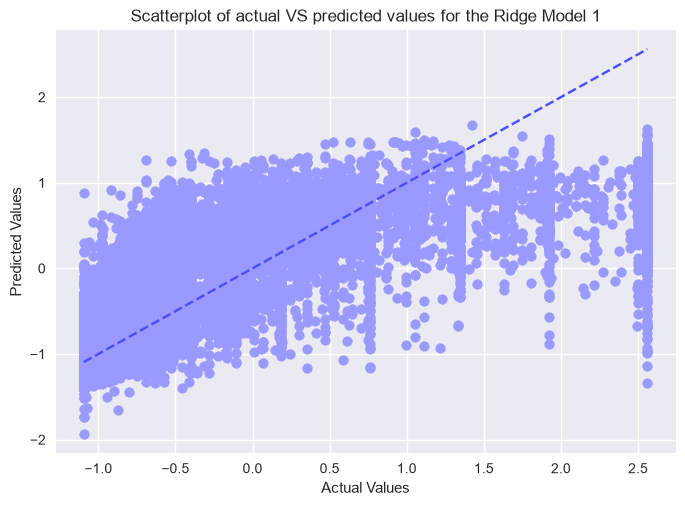

In [15]:
# Creating a scatterplot of actual VS predicted values for Ridge1
plt.scatter(y_test_std, y_pred_test_Ridge_1, color = '#9999ff')
# Adding the plot title and axis labels
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Scatterplot of actual VS predicted values for the Ridge Model 1')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()], 
         [y_test_std.min(), y_test_std.max()], linestyle = '--', c = '#4d4dff')
plt.show();

### 3.2.2. Random Forest (RF) Regression

Being an emsemble method, RF utilises Bootstrap Aggregation (Bagging) to generate multiple independent trees. Thus, it is insensitive to features' scale, not requiring feature standardisation (Segal, 2004). However, to enable models' comparability, the scaled DV was

Due to IVs possessing original scales, comparing importances directly might be unmeaningful. Yet, for the assessment's purpose, solely model evaluation metrics were compared.

In [16]:
# Instantiating the model
RF_model_1 = RandomForestRegressor(n_estimators=100, random_state=28)
# Timing the training process
start_time_RF_1 = time.time()
# Fitting the model to the training data
RF_model_1.fit(X_train, y_train_std.ravel())
# End time
end_time_RF_1 = time.time()
# Demonstrating the coefficients of the RF Regression Model 1 
pd.DataFrame(RF_model_1.feature_importances_,
              df_merged.drop('price_dollars', axis = 1).columns,
              columns = ['Importances']).sort_values(by = 'Importances', 
                                                     ascending = False).round(4)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",28
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

,Importances
Entire home/apt,0.3308
longitude,0.1227
latitude,0.0867
Days_per_year_available,0.0524
Unnamed: 0,0.0454
Piece_and_Quiet,0.0324
Big_private_Studio_by_Astoria,0.0324
Quiet_East_Place_with_Garden,0.0318
Subway_Closeness,0.0312
New_apt_with_view,0.0312


In [17]:
# Calculating the time taken for training
training_time_RF_1 = end_time_RF_1 - start_time_RF_1
print(f'Training time of RF Model 1: {training_time_RF_1:.4f} seconds')

Training time of RF Model 1: 25.4252 seconds


In [18]:
# Predicting on the training set
y_pred_train_RF_1 = RF_model_1.predict(X_train)
# Evaluating the RF Model 1 on the training set
R2_RF_1_train = r2_score(y_train_std, y_pred_train_RF_1)
MSE_RF_1_train = mean_squared_error(y_train_std, y_pred_train_RF_1)
MAE_RF_1_train = mean_absolute_error(y_train_std, y_pred_train_RF_1)
#printing the values
print(f'The R-squared of the Random Forest 1 on the training set: {R2_RF_1_train * 100:.2f}%')
print(f'The MSE of the Random Forest 1 on the training set: {MSE_RF_1_train:.2f}')
print(f'The MAE of the Random Forest 1 on the training set: {MAE_RF_1_train:.2f}')

The R-squared of the Random Forest 1 on the training set: 93.51%
The MSE of the Random Forest 1 on the training set: 0.06
The MAE of the Random Forest 1 on the training set: 0.18


In [19]:
# Predicting the target values on the validation data using the trained model
y_pred_val_RF_1 = RF_model_1.predict(X_val)
# Evaluating the model performance on the validation data using R-squared
R2_RF_1_val = r2_score(y_val_std, y_pred_val_RF_1)
print(f'The R-squared of the Random Forest 1 on the validation set: {R2_RF_1_val * 100:.2f}%')
# Evaluating the model performance on the validation data using Mean Squared Error
MSE_RF_1_val = mean_squared_error(y_val_std, y_pred_val_RF_1)
print(f'The MSE of the Random Forest 1 on the validation set: {MSE_RF_1_val:.2f}')
# Evaluating the model performance on the validation data using Mean Absolute Error
MAE_RF_1_val = mean_absolute_error(y_val_std, y_pred_val_RF_1)
print(f'The MAE of the Random Forest 1 on the validation set is: {MAE_RF_1_val:.2f}')

The R-squared of the Random Forest 1 on the validation set: 54.40%
The MSE of the Random Forest 1 on the validation set: 0.46
The MAE of the Random Forest 1 on the validation set is: 0.48


In [20]:

y_pred_test_RF_1 = RF_model_1.predict(X_test)
# Evaluating the RF model on the test set
R2_RF_1_test = r2_score(y_test_std, y_pred_test_RF_1)
MSE_RF_1_test = mean_squared_error(y_test_std, y_pred_test_RF_1)
MAE_RF_1_test = mean_absolute_error(y_test_std, y_pred_test_RF_1)
# Printing the evaluation metrics on the test set
print(f'The R-squared of the Random Forest 1 on the test set: {R2_RF_1_test * 100:.2f}%')
print(f'The MSE of the Random Forest 1 on the test set: {MSE_RF_1_test:.2f}')
print(f'The MAE of the Random Forest 1 on the test set: {MAE_RF_1_test:.2f}')

The R-squared of the Random Forest 1 on the test set: 54.67%
The MSE of the Random Forest 1 on the test set: 0.45
The MAE of the Random Forest 1 on the test set: 0.48


#### Visualising

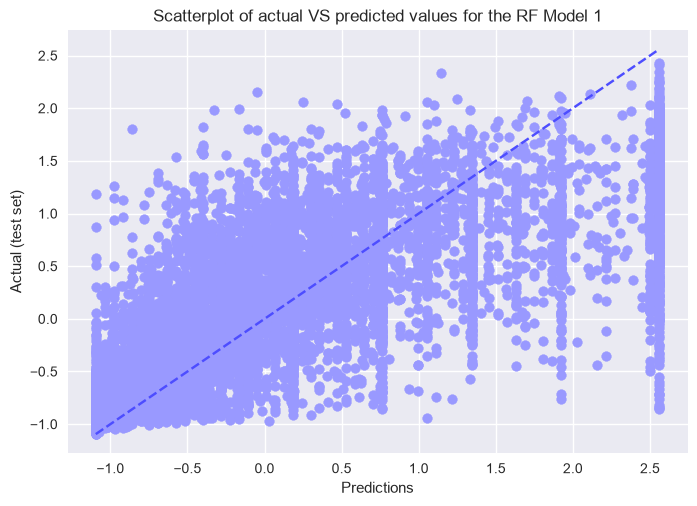

In [21]:
# plotting the scatter plot of actual VS Predicted Values for the RF Model 1
plt.scatter(y_test_std, y_pred_test_RF_1, color = '#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle = '--', c = '#4d4dff')
#setting the axes labels and title
plt.xlabel('Predictions')
plt.ylabel('Actual (test set)')
plt.title('Scatterplot of actual VS predicted values for the RF Model 1')
plt.show();

### 3.2.3. Model 3(i): XGBoost Regression

XGBoost was selected as a 3rd model since despite being a tree-based algorithm like RF, it differs in learning methodology, utilising gradient-based optimisation computing gradients for each feature (Avanijaa, 2021). XBGoost sequentially builds trees where each tree corrects the previous one's errors, while striving for loss function minimisation. Thus, it is insensitive to features' scales, and similarly to RF, solely the DV was scaled.

In [22]:
# Creating an instance of XGBRegressor without HyperParameter Tuning 
#(Default Parameters)
#setting the random seed for results' reproducibility
XGB_model_1 = xgb.XGBRegressor(seed=28)
# Timing the training process
start_time_XGB_1 = time.time()
# Fitting the model on the training data
XGB_model_1.fit(X_train, y_train_std.ravel())
# End time
end_time_XGB_1 = time.time()
# Demonstrating the coefficients of the XGB Regression Model 1
pd.DataFrame(XGB_model_1.feature_importances_,
              df_merged.drop('price_dollars', axis = 1).columns,
              columns = ['Importances']).sort_values(by = 'Importances', 
                                                     ascending = False).round(4)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


,Importances
Entire home/apt,0.5782
longitude,0.0482
Manhattan,0.0429
latitude,0.0383
Days_per_year_available,0.0350
minimum_nights,0.0324
number_of_reviews,0.0231
total_host_listings,0.0220
Private room,0.0193
reviews_per_month,0.0156


In [23]:
# Calculating the time taken for training
training_time_XGB_1 = end_time_XGB_1 - start_time_XGB_1
print(f'Training time of XGB Model 1: {training_time_XGB_1:.4f} seconds')

Training time of XGB Model 1: 0.3449 seconds


In [24]:
# Predicting the target values on the training data using the trained model
y_pred_XGB_1_train = XGB_model_1.predict(X_train)
# Evaluating the model performance on the training data using the R2, MSE and MAE
R2_XGB_1_train = r2_score(y_train_std, y_pred_XGB_1_train)
MSE_XGB_1_train = mean_squared_error(y_train_std, y_pred_XGB_1_train)
MAE_XGB_1_train = mean_absolute_error(y_train_std, y_pred_XGB_1_train)
#printing the scores
print(f'The R-squared of the XGBoost Regression 1 on the training set: {R2_XGB_1_train * 100:.2f}%')
print(f'The MSE of the XGBoost Regression 1 on the training set: {MSE_XGB_1_train:.2f}')
print(f'The MAE of the XGBoost Regression 1 on the training set is: {MAE_XGB_1_train:.2f}')

The R-squared of the XGBoost Regression 1 on the training set: 75.15%
The MSE of the XGBoost Regression 1 on the training set: 0.25
The MAE of the XGBoost Regression 1 on the training set is: 0.35


In [25]:
# Predicting the target values on the validation data using the trained model
y_pred_XGB_1_val = XGB_model_1.predict(X_val)
# Evaluating the model performance on the validation data using using the R2, MSE 
R2_XGB_1_val = r2_score(y_val_std, y_pred_XGB_1_val)
MSE_XGB_1_val = mean_squared_error(y_val_std, y_pred_XGB_1_val)
MAE_XGB_1_val = mean_absolute_error(y_val_std, y_pred_XGB_1_val)
#printing the scores
print(f'The R-squared of the XGBoost Regression 1 on the validation set: {R2_XGB_1_val * 100:.2f}%')
print(f'The MSE of the XGBoost Regression 1 on the validation set: {MSE_XGB_1_val:.2f}')
print(f'The MAE of the XGBoost Regression 1 on the validation set is: {MAE_XGB_1_val:.2f}')

The R-squared of the XGBoost Regression 1 on the validation set: 54.50%
The MSE of the XGBoost Regression 1 on the validation set: 0.45
The MAE of the XGBoost Regression 1 on the validation set is: 0.48


In [26]:
# Predicting the target values on the test data using the trained model
y_pred_XGB_1_test = XGB_model_1.predict(X_test)
# Evaluating the model performance on the test data using the R2, MSE and MAE
R2_XGB_1_test = r2_score(y_test_std, y_pred_XGB_1_test)
MSE_XGB_1_test = mean_squared_error(y_test_std, y_pred_XGB_1_test)
MAE_XGB_1_test = mean_absolute_error(y_test_std, y_pred_XGB_1_test)
#printing the scores
print(f'The R-squared of the XGBoost Regression 1 on the test set: {R2_XGB_1_test  * 100:.2f}%')
print(f'The MSE of the XGBoost Regression 1 on the test set: {MSE_XGB_1_test:.2f}')
print(f'The MAE of the XGBoost Regression 1 on the test set is: {MAE_XGB_1_test:.2f}')

The R-squared of the XGBoost Regression 1 on the test set: 54.06%
The MSE of the XGBoost Regression 1 on the test set: 0.46
The MAE of the XGBoost Regression 1 on the test set is: 0.48


#### Visualising

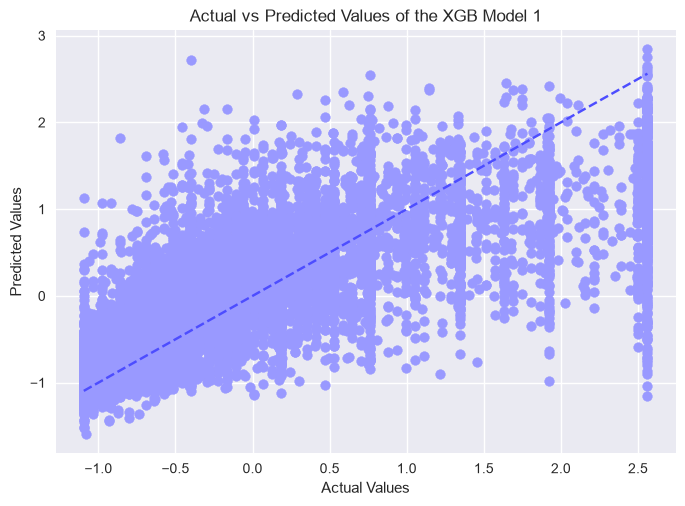

In [27]:
# Creating a scatterplot of actual VS predicted valuesfor XGB 1
plt.scatter(y_test_std, y_pred_XGB_1_test, color = '#9999ff')
# Adding the plot title and axis labels
plt.title('Actual vs Predicted Values of the XGB Model 1')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()], 
         [y_test_std.min(), y_test_std.max()], linestyle = '--', color = '#4d4dff')
plt.show();

### 3.2.4. Shallow Multilayer Perceptron (MLP) Regression (Scikit-Learn)

Starting with the most basic MLP Regression using Scikit-Learn and 1 hidden layer with 100 Neurons and 1000 iterations to establish baseline performance, iteratively changing parameters in each model to obtain best parameters for subsequent model improvement.

In [28]:
# Creating the MLP regression model
#1 layer
MLP_model_basic_1 = MLPRegressor(hidden_layer_sizes=(100),
                    #ReLU (Rectified Linear Unit) -f(x) = max(0, x)
                    #- high speed and computational efficiency
                     #resulting in faster traing and improved model performance
                         activation='relu',
                     #Adam (Adaptive Moment Estimation) optimiser 
                     #commonly-used gradient descent optimisation algorithm        
                         solver='adam',
                        # N times to pass through the entire DS during trainig
                         max_iter=1000,
                        #utilising the same random state for all models
                         random_state=28,
                          #printing loss at each iteration during training
                          verbose=True)
#Adam optimiser - computes individual adaptive learning rates for various paramete
#of 1st and 2nd gradient moments -> adaptive learning rate
#& utilises momentum to accelerate model convergence
#it combines  AdaGrad and RMSProp's optimisers' benefits

In [29]:
# Timing the training process
start_time_MLP_basic_1 = time.time()
# Fitting the model to the standardised training data
MLP_model_basic_1.fit(X_train_std, y_train_std.ravel())
#end of training
end_time_MLP_basic_1 = time.time()

Iteration 1, loss = 0.30918457
Iteration 2, loss = 0.25647824
Iteration 3, loss = 0.24888109
Iteration 4, loss = 0.24525557
Iteration 5, loss = 0.24321017
Iteration 6, loss = 0.24171052
Iteration 7, loss = 0.23997359
Iteration 8, loss = 0.23894615
Iteration 9, loss = 0.23827177
Iteration 10, loss = 0.23747786
Iteration 11, loss = 0.23667801
Iteration 12, loss = 0.23600689
Iteration 13, loss = 0.23539315
Iteration 14, loss = 0.23454859
Iteration 15, loss = 0.23425204
Iteration 16, loss = 0.23351472
Iteration 17, loss = 0.23332380
Iteration 18, loss = 0.23345716
Iteration 19, loss = 0.23215872
Iteration 20, loss = 0.23253958
Iteration 21, loss = 0.23206101
Iteration 22, loss = 0.23145947
Iteration 23, loss = 0.23132196
Iteration 24, loss = 0.23106096
Iteration 25, loss = 0.23066677
Iteration 26, loss = 0.23038917
Iteration 27, loss = 0.22993447
Iteration 28, loss = 0.22978300
Iteration 29, loss = 0.22966274
Iteration 30, loss = 0.22955391
Iteration 31, loss = 0.22873517
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.",100
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",28
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


In [30]:
training_time_MLP_basic_1 = end_time_MLP_basic_1 - start_time_MLP_basic_1
print(f'Training time of MLP Model 1: {training_time_MLP_basic_1:.2f} seconds')

Training time of MLP Model 1: 6.44 seconds


In [31]:
# Accessing the loss curve over all iterations
loss_curve_MLP_basic_1 = MLP_model_basic_1.loss_curve_
# Printing the learning rate and loss curve over all iterations
print(f"Learning rate: {MLP_model_basic_1.learning_rate}")
print(f"Loss curve: {loss_curve_MLP_basic_1}")

Learning rate: constant
Loss curve: [np.float64(0.309184566269838), np.float64(0.25647824399091496), np.float64(0.2488810864106723), np.float64(0.24525556741017862), np.float64(0.24321017311873463), np.float64(0.24171052022458264), np.float64(0.23997359440124438), np.float64(0.23894614670718264), np.float64(0.2382717684527731), np.float64(0.23747786193723613), np.float64(0.23667801268832336), np.float64(0.23600689305768655), np.float64(0.23539315160310884), np.float64(0.2345485878116446), np.float64(0.2342520406194266), np.float64(0.23351472123054634), np.float64(0.233323798932515), np.float64(0.23345715957593396), np.float64(0.23215872159113982), np.float64(0.23253958213112347), np.float64(0.23206101371699686), np.float64(0.2314594711030665), np.float64(0.23132195545468964), np.float64(0.23106095986120387), np.float64(0.23066676737218372), np.float64(0.2303891713086431), np.float64(0.22993446718244265), np.float64(0.22978300493799042), np.float64(0.22966273626957878), np.float64(0.229

In [32]:
# Making predictions on the training set
y_pred_MLP_basic_1_train = MLP_model_basic_1.predict(X_train_std)
# Computing the R-squared, MSE, and MAE metrics on the training set
R2_MLP_basic_1_train = r2_score(y_train_std.ravel(), y_pred_MLP_basic_1_train.ravel())
MSE_MLP_basic_1_train = mean_squared_error(y_train_std.ravel(), y_pred_MLP_basic_1_train.ravel())
MAE_MLP_basic_1_train = mean_absolute_error(y_train_std.ravel(), y_pred_MLP_basic_1_train.ravel())
# Printing the metrics on the training set
print(f'R2 of the MLP Model 1 on the training set: {R2_MLP_basic_1_train * 100:.2f}%')
print(f'MSE of the MLP Model 1 on the training set: {MSE_MLP_basic_1_train:.2f}')
print(f'MAE of the MLP Model 1 the training set: {MAE_MLP_basic_1_train:.2f}')

R2 of the MLP Model 1 on the training set: 57.70%
MSE of the MLP Model 1 on the training set: 0.42
MAE of the MLP Model 1 the training set: 0.47


In [33]:
# Predicting on the validation data
y_pred_MLP_basic_1_val = MLP_model_basic_1.predict(X_val_std)
# Evaluating the the MLP model 1 performanceon the validation data using R-squared
R2_MLP_basic_1_val = r2_score(y_val_std.ravel(), y_pred_MLP_basic_1_val.ravel())
MSE_MLP_basic_1_val = mean_squared_error(y_val_std.ravel(), y_pred_MLP_basic_1_val.ravel())
MAE_MLP_basic_1_val = mean_absolute_error(y_val_std.ravel(), y_pred_MLP_basic_1_val.ravel())
#printing the scores
print(f'The R-squared of the MLP Model 1 on the validation set: {R2_MLP_basic_1_val * 100:.2f}%')
print(f'The MSE of the MLP Model 1 on the validation set: {MSE_MLP_basic_1_val:.2f}')
print(f'The MAE of the MLP Model 1 on the validation set: {MAE_MLP_basic_1_val:.2f}')

The R-squared of the MLP Model 1 on the validation set: 49.87%
The MSE of the MLP Model 1 on the validation set: 0.50
The MAE of the MLP Model 1 on the validation set: 0.51


In [34]:
# Predicting on the test data
y_pred_MLP_basic_1_test = MLP_model_basic_1.predict(X_test_std)
# Evaluating the MLP model 1 on the test data using R-squared, MSE, and MAE
R2_MLP_basic_1_test = r2_score(y_test_std.ravel(), y_pred_MLP_basic_1_test.ravel())
MSE_MLP_basic_1_test = mean_squared_error(y_test_std.ravel(), y_pred_MLP_basic_1_test.ravel())
MAE_MLP_basic_1_test = mean_absolute_error(y_test_std.ravel(), y_pred_MLP_basic_1_test.ravel())
#printing the scores
print(f'The R-squared of the MLP Model 1 on the test set: {R2_MLP_basic_1_test * 100:.2f}')
print(f'The MSE of the MLP Model 1 on the test set: {MSE_MLP_basic_1_test:.2f}')
print(f'The MAE of the MLP Model 1 on the test set: {MAE_MLP_basic_1_test:.2f}')

The R-squared of the MLP Model 1 on the test set: 50.02
The MSE of the MLP Model 1 on the test set: 0.50
The MAE of the MLP Model 1 on the test set: 0.51


#### Visualising

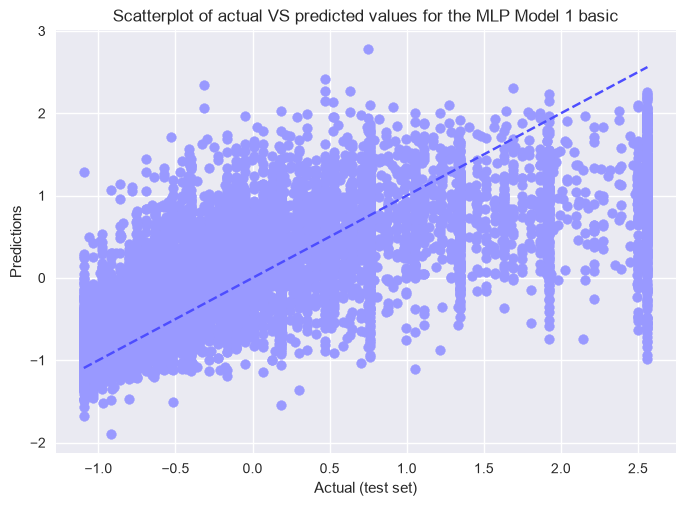

In [35]:
# plotting the scatter plot of Actual VS Predicted Values for MLP 1
plt.scatter(y_test_std, y_pred_MLP_basic_1_test, color='#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle='--', c='#4d4dff')
# Setting the axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual VS predicted values for the MLP Model 1 basic')
plt.show();

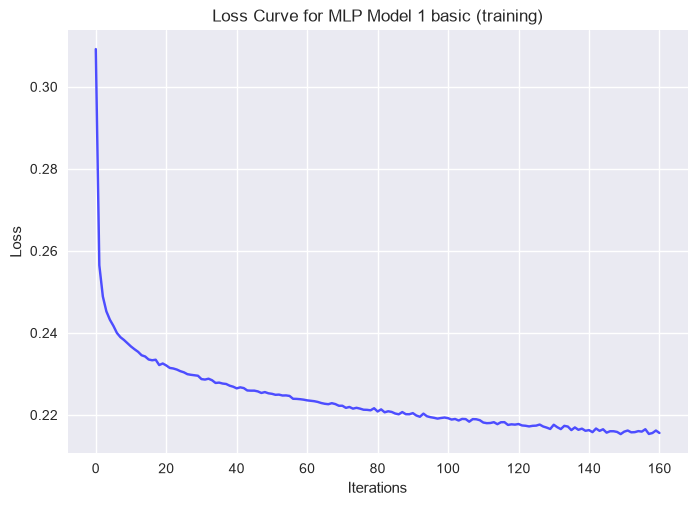

In [36]:
# Plotting the loss curve for MLP 1 basic
#**It should be noted that Scikit-Learn does not allow to 
#sccess the validation loss curve. Thus, solely the training 
#learning curve was plotted
plt.plot(MLP_model_basic_1.loss_curve_,  color = '#4d4dff')
#setting the labels and title
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve for MLP Model 1 basic (training)')
plt.show();

MLP_1 with 1 hidden layer provided decent performance. Thus, it was examined whether adding another hidden layer (100/2) would enhance performance.

### 3.2.5. MLP_Model_2: increasing the numver of hidden_layers to 2

In [37]:
# Creating the MLP regression model
#2 layers 
MLP_model_2 = MLPRegressor(hidden_layer_sizes=(100, 50),
                         activation='relu',
                         solver='adam',
                        #learning rate
                         #alpha=0.001,
                        # N times to pass through the entire DS during trainig
                         max_iter=1000,
                         random_state=28,
                          #printing loss at each iteration during training
                          verbose=True)
# Timing the training process
start_time_MLP_2 = time.time()
# Fitting the model to the training data
MLP_model_2.fit(X_train_std, y_train_std.ravel())
end_time_MLP_2 = time.time()

Iteration 1, loss = 0.28904655
Iteration 2, loss = 0.25086482
Iteration 3, loss = 0.24377069
Iteration 4, loss = 0.24070020
Iteration 5, loss = 0.23765537
Iteration 6, loss = 0.23557538
Iteration 7, loss = 0.23384451
Iteration 8, loss = 0.23191677
Iteration 9, loss = 0.23054311
Iteration 10, loss = 0.22918599
Iteration 11, loss = 0.22831052
Iteration 12, loss = 0.22670148
Iteration 13, loss = 0.22524279
Iteration 14, loss = 0.22425875
Iteration 15, loss = 0.22358604
Iteration 16, loss = 0.22166111
Iteration 17, loss = 0.22111576
Iteration 18, loss = 0.21929960
Iteration 19, loss = 0.21870336
Iteration 20, loss = 0.21784873
Iteration 21, loss = 0.21682589
Iteration 22, loss = 0.21668619
Iteration 23, loss = 0.21530643
Iteration 24, loss = 0.21445691
Iteration 25, loss = 0.21249764
Iteration 26, loss = 0.21178580
Iteration 27, loss = 0.21123936
Iteration 28, loss = 0.21039819
Iteration 29, loss = 0.20924156
Iteration 30, loss = 0.20893186
Iteration 31, loss = 0.20765582
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",28
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


In [38]:
training_time_MLP_2 = end_time_MLP_2 - start_time_MLP_2
print(f'Training time of MLP Model 2: {training_time_MLP_2:.2f} seconds')

Training time of MLP Model 2: 19.22 seconds


In [39]:
# Accessing the loss curve over all iterations
loss_curve_MLP_2 = MLP_model_2.loss_curve_
# Printing the learning rate and loss curve over all iterations
print(f"Learning rate: {MLP_model_2.learning_rate}")
print(f"Loss curve: {loss_curve_MLP_2}")

Learning rate: constant
Loss curve: [np.float64(0.28904655287150555), np.float64(0.2508648232812114), np.float64(0.2437706914631511), np.float64(0.24070020091863645), np.float64(0.2376553728103967), np.float64(0.23557537523303854), np.float64(0.23384450671100648), np.float64(0.2319167738129307), np.float64(0.23054310583767026), np.float64(0.2291859889972095), np.float64(0.22831051510999306), np.float64(0.22670148404138482), np.float64(0.22524279198624914), np.float64(0.22425875216538574), np.float64(0.22358603830985405), np.float64(0.2216611140755008), np.float64(0.22111576038586986), np.float64(0.21929960217923478), np.float64(0.21870335944111816), np.float64(0.21784872554233425), np.float64(0.21682589140440411), np.float64(0.21668619304010503), np.float64(0.21530642828630484), np.float64(0.21445690838235493), np.float64(0.2124976423485576), np.float64(0.21178579993832064), np.float64(0.21123936422467568), np.float64(0.21039818531442997), np.float64(0.20924156056394136), np.float64(0.

In [40]:
# Make predictions on the training set
y_pred_MLP_2_train = MLP_model_2.predict(X_train_std)
# Compute the R-squared, MSE, and MAE metrics on the training set
R2_MLP_2_train = r2_score(y_train_std.ravel(), y_pred_MLP_2_train.ravel())
MSE_MLP_2_train = mean_squared_error(y_train_std.ravel(), y_pred_MLP_2_train.ravel())
MAE_MLP_2_train = mean_absolute_error(y_train_std.ravel(), y_pred_MLP_2_train.ravel())
# Print the metrics on the training set
print(f'R2 of the MLP Model 1 on the training set: {R2_MLP_2_train * 100:.2f}%')
print(f'MSE of the MLP Model 1 on the training set: {MSE_MLP_2_train:.2f}')
print(f'MAE of the MLP Model 1 the training set: {MAE_MLP_2_train:.2f}')

R2 of the MLP Model 1 on the training set: 72.03%
MSE of the MLP Model 1 on the training set: 0.28
MAE of the MLP Model 1 the training set: 0.39


In [41]:
# Predicting on the validation data
y_pred_MLP_2_val = MLP_model_2.predict(X_val_std)
# Evaluating the the MLP model 1 performance on the validation data using R-square
R2_MLP_2_val = r2_score(y_val_std.ravel(), y_pred_MLP_2_val.ravel())
MSE_MLP_2_val = mean_squared_error(y_val_std.ravel(), y_pred_MLP_2_val.ravel())
MAE_MLP_2_val = mean_absolute_error(y_val_std.ravel(), y_pred_MLP_2_val.ravel())
#printing the scores
print(f'The R-squared of the MLP Model 1 on the validation set: {R2_MLP_2_val * 100:.2f}%')
print(f'The MSE of the MLP Model 1 on the validation set: {MSE_MLP_2_val:.2f}')
print(f'The MAE of the MLP Model 1 on the validation set: {MAE_MLP_2_val:.2f}')

The R-squared of the MLP Model 1 on the validation set: 34.94%
The MSE of the MLP Model 1 on the validation set: 0.65
The MAE of the MLP Model 1 on the validation set: 0.58


In [42]:
# Predicting on the test data
y_pred_MLP_2_test = MLP_model_2.predict(X_test_std)
# Evaluating the MLP model 1 on the test data using R-squared, MSE, and MAE
R2_MLP_2_test = r2_score(y_test_std.ravel(), y_pred_MLP_2_test.ravel())
MSE_MLP_2_test = mean_squared_error(y_test_std.ravel(), y_pred_MLP_2_test.ravel())
MAE_MLP_2_test = mean_absolute_error(y_test_std.ravel(), y_pred_MLP_2_test.ravel())
#printing the scores
print(f'The R-squared of the MLP Model 1 on the test set: {R2_MLP_2_test * 100:.2f}%')
print(f'The MSE of the MLP Model 1 on the test set: {MSE_MLP_2_test:.2f}')
print(f'The MAE of the MLP Model 1 on the test set: {MAE_MLP_2_test:.2f}')

The R-squared of the MLP Model 1 on the test set: 33.96%
The MSE of the MLP Model 1 on the test set: 0.66
The MAE of the MLP Model 1 on the test set: 0.58


#### Visualising

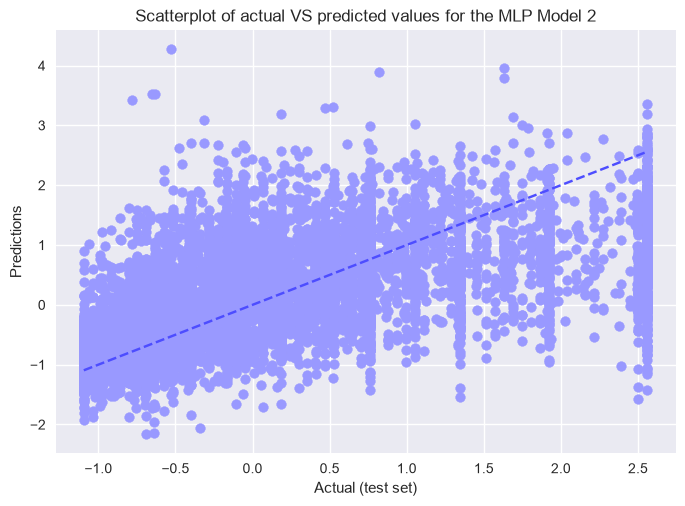

In [43]:
# plotting the scatter plot of Actual VS Predicted Values for MLP 2
plt.scatter(y_test_std, y_pred_MLP_2_test, color='#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle='--', c='#4d4dff')
# Setting the axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual VS predicted values for the MLP Model 2')
plt.show();

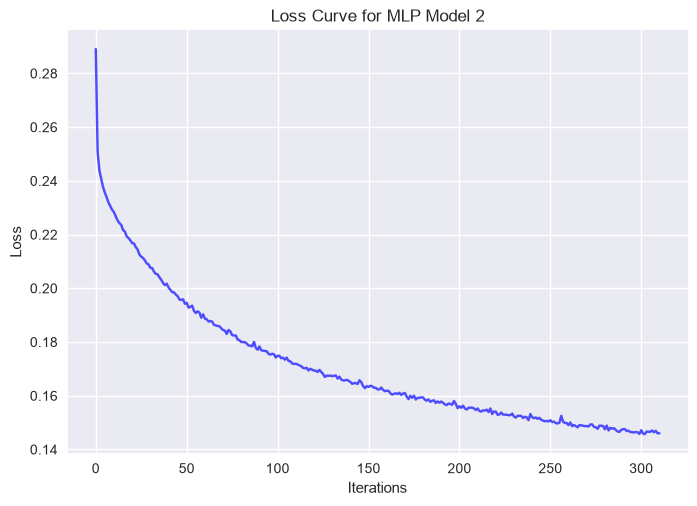

In [44]:
# Plotting the loss curve for MLP 2
plt.plot(MLP_model_2.loss_curve_,  color = '#4d4dff')
#setting the labels and title
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve for MLP Model 2')
plt.show();

Adding a second hidden layer resulted in significant overfitting.Thus, next the SGD optimiser with slower convergence was experimented with(same hyperparameters).

### 3.2.6. MLP_Model_3: Changing Optimiser (SGD)

In [45]:
# Creating the MLP regression model - same hyperparameters
#2 layers 
MLP_model_3 = MLPRegressor(hidden_layer_sizes=(100,50),
                         activation='relu',
                        # changing the optimiser
                         solver='sgd',
                        # N times to pass through the entire DS during trainig
                         max_iter=1000,
                         random_state=28,
                          #printing loss at each iteration during training
                          verbose=True)
# Timing the training process
start_time_MLP_3 = time.time()
# Fitting the model to the training data
MLP_model_3.fit(X_train_std, y_train_std.ravel())
end_time_MLP_3 = time.time()

Iteration 1, loss = 0.38956449
Iteration 2, loss = 0.29548295
Iteration 3, loss = 0.28132430
Iteration 4, loss = 0.27436034
Iteration 5, loss = 0.26983197
Iteration 6, loss = 0.26642209
Iteration 7, loss = 0.26384043
Iteration 8, loss = 0.26156556
Iteration 9, loss = 0.25979604
Iteration 10, loss = 0.25809516
Iteration 11, loss = 0.25677374
Iteration 12, loss = 0.25552901
Iteration 13, loss = 0.25436488
Iteration 14, loss = 0.25341735
Iteration 15, loss = 0.25247300
Iteration 16, loss = 0.25172876
Iteration 17, loss = 0.25089772
Iteration 18, loss = 0.25020012
Iteration 19, loss = 0.24953340
Iteration 20, loss = 0.24889979
Iteration 21, loss = 0.24835188
Iteration 22, loss = 0.24782058
Iteration 23, loss = 0.24730168
Iteration 24, loss = 0.24679007
Iteration 25, loss = 0.24634286
Iteration 26, loss = 0.24592599
Iteration 27, loss = 0.24548039
Iteration 28, loss = 0.24504963
Iteration 29, loss = 0.24470752
Iteration 30, loss = 0.24435973
Iteration 31, loss = 0.24399702
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",28
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


In [46]:
training_time_MLP_3 = end_time_MLP_3 - start_time_MLP_3
print(f'Training time of MLP Model 3: {training_time_MLP_3:.2f} seconds')

Training time of MLP Model 3: 17.25 seconds


In [47]:
# Accessing the loss curve over all iterations
loss_curve_MLP_3 = MLP_model_3.loss_curve_
# Printing the learning rate and loss curve over all iterations
print(f"Learning rate: {MLP_model_3.learning_rate}")
print(f"Loss curve: {loss_curve_MLP_3}")

Learning rate: constant
Loss curve: [np.float64(0.3895644936660838), np.float64(0.2954829521057768), np.float64(0.2813243047758652), np.float64(0.2743603384760822), np.float64(0.2698319738915269), np.float64(0.2664220905377991), np.float64(0.2638404329941932), np.float64(0.26156555945051513), np.float64(0.2597960360846004), np.float64(0.25809516108062736), np.float64(0.25677374454017265), np.float64(0.255529012653234), np.float64(0.25436487813677344), np.float64(0.25341735230901763), np.float64(0.2524730043117375), np.float64(0.25172876208113004), np.float64(0.2508977177101233), np.float64(0.2502001164124261), np.float64(0.24953340451737724), np.float64(0.24889978530747378), np.float64(0.24835188408945208), np.float64(0.2478205767515104), np.float64(0.2473016798076173), np.float64(0.24679006932984474), np.float64(0.24634286291525612), np.float64(0.24592598558263143), np.float64(0.24548039041388459), np.float64(0.24504963030544819), np.float64(0.2447075239882738), np.float64(0.244359734

In [48]:
# Making predictions on the training set
y_pred_MLP_3_train = MLP_model_3.predict(X_train_std)
# Computing the R-squared, MSE, and MAE metrics on the training set
R2_MLP_3_train = r2_score(y_train_std.ravel(), y_pred_MLP_3_train.ravel())
MSE_MLP_3_train = mean_squared_error(y_train_std.ravel(), y_pred_MLP_3_train.ravel())
MAE_MLP_3_train = mean_absolute_error(y_train_std.ravel(), y_pred_MLP_3_train.ravel())
# Printing the metrics on the training set
print(f'R2 of the MLP Model 3 on the training set: {R2_MLP_3_train * 100:.2f}%')
print(f'MSE of the MLP Model 3 on the training set: {MSE_MLP_3_train:.2f}')
print(f'MAE of the MLP Model 3 the training set: {MAE_MLP_3_train:.2f}')

R2 of the MLP Model 3 on the training set: 56.45%
MSE of the MLP Model 3 on the training set: 0.44
MAE of the MLP Model 3 the training set: 0.47


In [49]:
# Predicting on the validation data
y_pred_MLP_3_val = MLP_model_3.predict(X_val_std)
# Evaluating the the MLP model 1 performanceon the validation data using R-squared
R2_MLP_3_val = r2_score(y_val_std.ravel(), y_pred_MLP_3_val.ravel())
MSE_MLP_3_val = mean_squared_error(y_val_std.ravel(), y_pred_MLP_3_val.ravel())
MAE_MLP_3_val = mean_absolute_error(y_val_std.ravel(), y_pred_MLP_3_val.ravel())
print(f'The R-squared of the MLP Model 3 on the validation set: {R2_MLP_3_val * 100:.2f}%')
print(f'The MSE of the MLP Model 3 on the validation set: {MSE_MLP_3_val:.2f}')
print(f'The MAE of the MLP Model 3 on the validation set: {MAE_MLP_3_val:.2f}')

The R-squared of the MLP Model 3 on the validation set: 50.66%
The MSE of the MLP Model 3 on the validation set: 0.49
The MAE of the MLP Model 3 on the validation set: 0.50


In [50]:
# Predicting on the test data
y_pred_MLP_3_test = MLP_model_3.predict(X_test_std)
# Evaluating the MLP model 1 on the test data using R-squared, MSE, and MAE
R2_MLP_3_test = r2_score(y_test_std.ravel(), y_pred_MLP_3_test.ravel())
MSE_MLP_3_test = mean_squared_error(y_test_std.ravel(), y_pred_MLP_3_test.ravel())
MAE_MLP_3_test = mean_absolute_error(y_test_std.ravel(), y_pred_MLP_3_test.ravel())
#printing the scores
print(f'The R-squared of the MLP Model 3 on the test set: {R2_MLP_3_test * 100:.2f}%')
print(f'The MSE of the MLP Model 3 on the test set: {MSE_MLP_3_test:.2f}')
print(f'The MAE of the MLP Model  on the test set: {MAE_MLP_3_test:.2f}')

The R-squared of the MLP Model 3 on the test set: 51.12%
The MSE of the MLP Model 3 on the test set: 0.49
The MAE of the MLP Model  on the test set: 0.50


#### Visualising

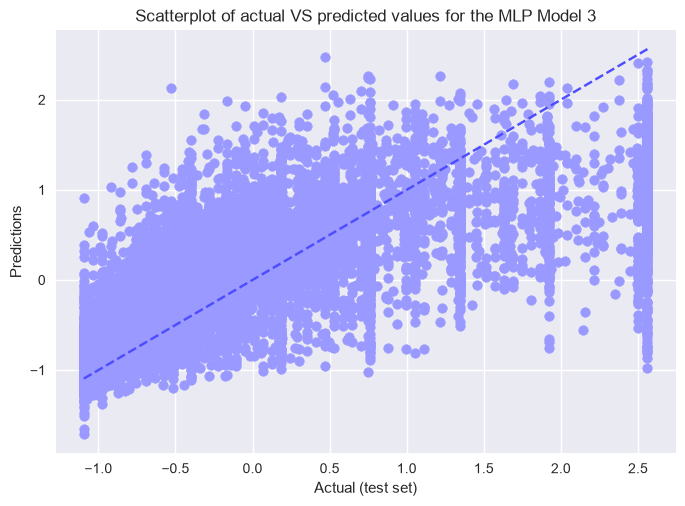

In [51]:
# plotting the scatter plot of Actual VS Predicted Values for MLP 
plt.scatter(y_test_std, y_pred_MLP_3_test, color = '#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle = '--', c = '#4d4dff')
# setting the axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual VS predicted values for the MLP Model 3')
plt.show();

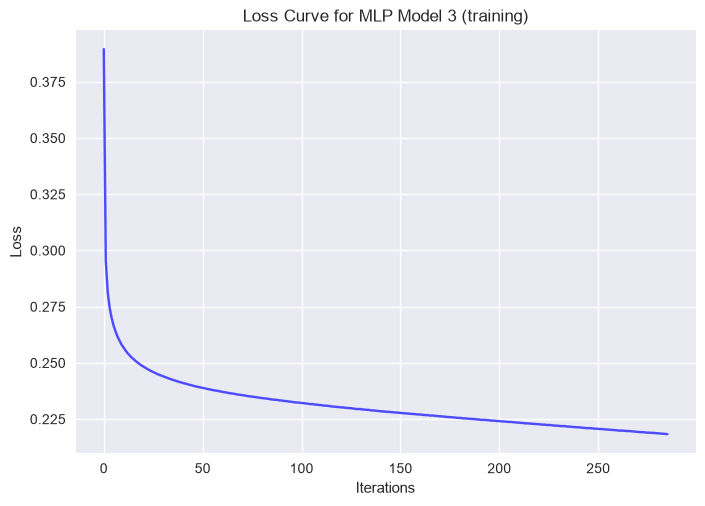

In [52]:
# Plotting the loss curve
plt.plot(MLP_model_3.loss_curve_,  color = '#4d4dff')
#setting the axes labels and title
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve for MLP Model 3 (training)')
plt.show();

SGD decreased overfitting.The next model will revert to adam, significantly reducing the learning rate to tackle the same issue.

### 3.2.7. MLP_Model_4 (Scikit-Learn), decreased learning rate

In [53]:
#Slower training process -> slower weight updates ->
# can increase training stability,however, slower.
# Creating the MLP regression model
                        #keeping the number of neurons in hidden layers
MLP_model_4 = MLPRegressor(hidden_layer_sizes=(100,50),
                         activation='relu',
                           #going back to adam
                         solver='adam',
                        #decreasing the learning rate to prevent overfitting
                         alpha=0.00001,
                        #same number of iterations
                         max_iter=1000,
                         random_state=28,
                       #printing loss at each iteration during training
                         verbose=True)
# Timing the training process
start_time_MLP_4 = time.time()
# Fitting the MLP model to the training data
MLP_model_4.fit(X_train_std, y_train_std.ravel())
end_time_MLP_4 = time.time()

Iteration 1, loss = 0.28901699
Iteration 2, loss = 0.25088045
Iteration 3, loss = 0.24370278
Iteration 4, loss = 0.24071937
Iteration 5, loss = 0.23758719
Iteration 6, loss = 0.23544345
Iteration 7, loss = 0.23361522
Iteration 8, loss = 0.23182145
Iteration 9, loss = 0.23037037
Iteration 10, loss = 0.22908732
Iteration 11, loss = 0.22812525
Iteration 12, loss = 0.22646237
Iteration 13, loss = 0.22499169
Iteration 14, loss = 0.22410701
Iteration 15, loss = 0.22347215
Iteration 16, loss = 0.22146426
Iteration 17, loss = 0.22104432
Iteration 18, loss = 0.21911904
Iteration 19, loss = 0.21874742
Iteration 20, loss = 0.21747243
Iteration 21, loss = 0.21655710
Iteration 22, loss = 0.21621380
Iteration 23, loss = 0.21492793
Iteration 24, loss = 0.21399436
Iteration 25, loss = 0.21199270
Iteration 26, loss = 0.21142014
Iteration 27, loss = 0.21069912
Iteration 28, loss = 0.20975068
Iteration 29, loss = 0.20903359
Iteration 30, loss = 0.20829314
Iteration 31, loss = 0.20701866
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",1e-05
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",28
,"verbose verbose: bool, default=FalseWhether to print progress messages to stdout.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001


In [54]:
training_time_MLP_4 = end_time_MLP_4 - start_time_MLP_4
print(f'The training time of MLP Model 4: {training_time_MLP_4:.2f} seconds')

The training time of MLP Model 4: 19.04 seconds


In [55]:
# Making predictions on the training set
y_pred_MLP_4_train = MLP_model_4.predict(X_train_std)
# Computing the R2, MSE, and MAE metrics on the training set
R2_MLP_4_train = r2_score(y_train_std.ravel(), y_pred_MLP_4_train.ravel())
MSE_MLP_4_train = mean_squared_error(y_train_std.ravel(), y_pred_MLP_4_train.ravel())
MAE_MLP_4_train = mean_absolute_error(y_train_std.ravel(), y_pred_MLP_4_train.ravel())
# Printing the metrics on the training set
print(f'R2 of the MLP Model 4 on the training set: {R2_MLP_4_train * 100:.2f}%')
print(f'MSE of the MLP Model 4 on the training set: {MSE_MLP_4_train:.2f}')
print(f'MAE of the MLP Model 4 on the training set: {MAE_MLP_4_train:.2f}')

R2 of the MLP Model 4 on the training set: 71.94%
MSE of the MLP Model 4 on the training set: 0.28
MAE of the MLP Model 4 on the training set: 0.38


In [56]:
# Predicting on the validation data
y_pred_MLP_4_val = MLP_model_4.predict(X_val_std)
# Evaluating the the MLP model 1 performanceon the validation data using R2, MSE,MAE
R2_MLP_4_val = r2_score(y_val_std.ravel(), y_pred_MLP_4_val.ravel())
MSE_MLP_4_val = mean_squared_error(y_val_std.ravel(), y_pred_MLP_4_val.ravel())
MAE_MLP_4_val = mean_absolute_error(y_val_std.ravel(), y_pred_MLP_4_val.ravel())
#printing the scores
print(f'The R-squared of the MLP Model 4 on the validation set: {R2_MLP_4_val * 100:.2f}%')
print(f'The MSE of the MLP Model 4 on the validation set: {MSE_MLP_4_val:.2f}')
print(f'The MAE of the MLP Model 4 on the validation set: {MAE_MLP_4_val:.2f}')

The R-squared of the MLP Model 4 on the validation set: 34.68%
The MSE of the MLP Model 4 on the validation set: 0.65
The MAE of the MLP Model 4 on the validation set: 0.57


In [57]:
# Predicting on the test data
y_pred_MLP_4_test = MLP_model_4.predict(X_test_std)
# Evaluating the MLP model 1 on the test data using R2, MSE, and MAE
R2_MLP_4_test = r2_score(y_test_std.ravel(), y_pred_MLP_4_test.ravel())
MSE_MLP_4_test = mean_squared_error(y_test_std.ravel(), y_pred_MLP_4_test.ravel())
MAE_MLP_4_test = mean_absolute_error(y_test_std.ravel(), y_pred_MLP_4_test.ravel())
#printing the scores
print(f'The R-squared of the MLP Model 4 on the test set: {R2_MLP_4_test * 100:.2f}%')
print(f'The MSE of the MLP Model 4 on the test set: {MSE_MLP_4_test:.2f}')
print(f'The MAE of the MLP Model 4 on the test set: {MAE_MLP_4_test:.2f}')

The R-squared of the MLP Model 4 on the test set: 34.83%
The MSE of the MLP Model 4 on the test set: 0.65
The MAE of the MLP Model 4 on the test set: 0.57


#### Visualising

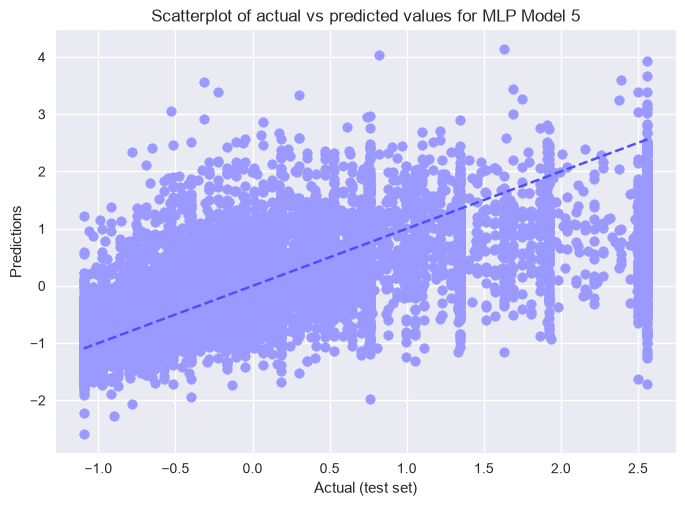

In [58]:
# plotting the scatter plot
plt.scatter(y_test_std, y_pred_MLP_4_test, color='#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle='--', c='#4d4dff')
# setting axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual vs predicted values for MLP Model 5')
plt.show();

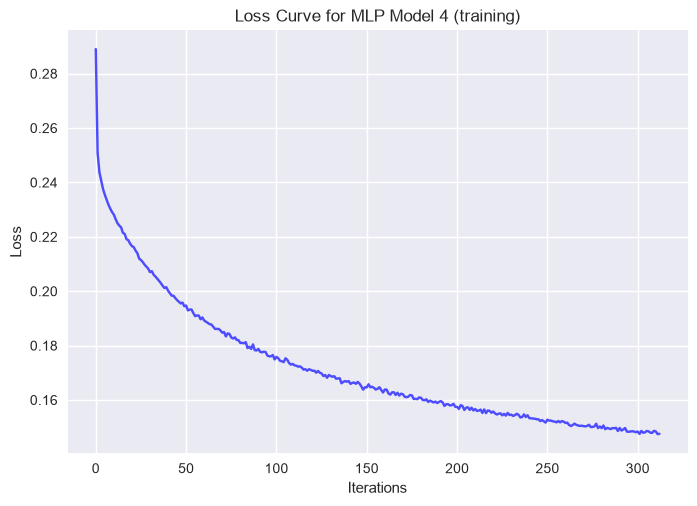

In [59]:
# Plotting the loss curve
plt.plot(MLP_model_4.loss_curve_,  color = '#4d4dff')
#setting the axes labels and title
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss Curve for MLP Model 4 (training)')
plt.show();

Yet, MLP_4 still significantly overfitted. Thus, Model_5 will decrease epochs' number(n_iter) by 2 and number of layers and neurons, attempting to mitigate it.

### 3.2.8. MLP_Model_5 (Keras)

In [60]:
#Defining the function to calculate the R2 score (coefficient of determination)  
#between true and predicted values
from keras import ops
def coeff_determination(y_true, y_pred):
    SS_res = ops.sum(ops.square(y_true-y_pred))
    SS_tot = ops.sum(ops.square(y_true - ops.mean(y_true)))
    return (1 - SS_res/(SS_tot + K.epsilon()))

In [61]:
# defining the simplified model architecture
MLP_Model_5_Keras = keras.Sequential([
    #1st MLP's fully-connected layer with 64 neurons, 
    #input shape=X_train_std (IVs) and ReLU activation function(same)
    keras.layers.Dense(units=64, input_dim=X_train_std.shape[1], activation='relu'),
    # MLP's output layer with 1 unit (regression task)
    #with a linear activation function (default) in order to predict out continuou
    #target variable('price_dollars')
    keras.layers.Dense(units=1)
])

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
# setting the random seed to ensure reproducibility of results
# setting the random seed for Numpy
np.random.seed(28)
# setting the random seed for Tensorflow
tf.random.set_seed(28)
#Compiling the model 
MLP_Model_5_Keras.compile(optimizer='adam',
                   loss='MSE',
                   metrics=['mean_squared_error', 'mean_absolute_error', coeff_determination])
# Timing the training process
start_time_MLP_5_keras =  time.time()
# Trainng the model
history_MLP_5_Keras = MLP_Model_5_Keras.fit(X_train_std, y_train_std, 
                         epochs=500, batch_size=128, 
                         validation_data=(X_val_std, y_val_std))
# End time
end_time_MLP_5_keras = time.time()

Epoch 1/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - coeff_determination: 0.3051 - loss: 0.6911 - mean_absolute_error: 0.6004 - mean_squared_error: 0.6911 - val_coeff_determination: 0.4616 - val_loss: 0.5332 - val_mean_absolute_error: 0.5331 - val_mean_squared_error: 0.5332
Epoch 2/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step - coeff_determination: 0.4782 - loss: 0.5178 - mean_absolute_error: 0.5167 - mean_squared_error: 0.5178 - val_coeff_determination: 0.4885 - val_loss: 0.5062 - val_mean_absolute_error: 0.5142 - val_mean_squared_error: 0.5062
Epoch 3/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - coeff_determination: 0.4964 - loss: 0.4998 - mean_absolute_error: 0.5045 - mean_squared_error: 0.4998 - val_coeff_determination: 0.4965 - val_loss: 0.4982 - val_mean_absolute_error: 0.5091 - val_mean_squared_error: 0.4982
Epoch 4/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - coeff_determination: 0.5043 - loss: 0.4920 - mean_absolute_error: 0.4996 - mean_squared_error: 0.4920 - val_

In [63]:
# Calculating the elapsed time
elapsed_time_MLP_5_keras = end_time_MLP_5_keras - start_time_MLP_5_keras
print(f"Elapsed time: {elapsed_time_MLP_5_keras:.2f} seconds")

Elapsed time: 84.25 seconds


In [64]:
# Making predictions on the training set
y_pred_MLP_Keras_5_train = MLP_Model_5_Keras.predict(X_train_std)
# Evaluating the model on the training set
#utilising the evaluate() method is a method, specific to the Keras API
#for Neural Networks
train_loss_MLP_Keras_5, train_mse_MLP_Keras_5, train_mae_MLP_Keras_5, train_r2_MLP_Keras_5 = MLP_Model_5_Keras.evaluate(X_train_std, 
                                                                     y_train_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_5_train = train_loss_MLP_Keras_5
R2_MLP_Keras_5_train = train_r2_MLP_Keras_5
MSE_MLP_Keras_5_train = train_mse_MLP_Keras_5
MAE_MLP_Keras_5_train = train_mae_MLP_Keras_5
#Printing the metrics on the training set
print(f'The loss MLP Keras Model 5 on the training set:  {loss_MLP_Keras_5_train:.4f}')
print(f'The R-squared of the MLP Keras Model 5 on the training set: {R2_MLP_Keras_5_train:.4f}')
print(f'The MSE of the MLP Keras Model 5 on the training set: {MSE_MLP_Keras_5_train:.4f}')
print(f'MAE of the MLP Keras Model 5 on the training set: {MAE_MLP_Keras_5_train:.4f}')

978/978 ━━━━━━━━━━━━━━━━━━━━ 0s 227us/step
978/978 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - coeff_determination: 0.5347 - loss: 0.4399 - mean_absolute_error: 0.4791 - mean_squared_error: 0.4399
The loss MLP Keras Model 5 on the training set:  0.4399
The R-squared of the MLP Keras Model 5 on the training set: 0.5347
The MSE of the MLP Keras Model 5 on the training set: 0.4399
MAE of the MLP Keras Model 5 on the training set: 0.4791


In [65]:
#Making predictions on the validation set
y_pred_MLP_Keras_5_val = MLP_Model_5_Keras.predict(X_val_std)
# Evaluating the performance 
##utilising the evaluate() method is a method, specific to the Keras API 
#for Neural Networks
val_loss_MLP_Keras_5, val_mse_MLP_Keras_5, val_mae_MLP_Keras_5, val_r2_MLP_Keras_5 = MLP_Model_5_Keras.evaluate(X_val_std, 
                                                                     y_val_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_5_val = val_loss_MLP_Keras_5
R2_MLP_Keras_5_val = val_r2_MLP_Keras_5
MSE_MLP_Keras_5_val = val_mse_MLP_Keras_5
MAE_MLP_Keras_5_val = val_mae_MLP_Keras_5
#Printing the metrics on the validation set
print(f'The loss MLP Keras Model 5 on the validation set:  {loss_MLP_Keras_5_val:.4f}')
print(f'The R-squared of the MLP Keras Model 5 on the validation set:  {R2_MLP_Keras_5_val:.4f}')
print(f'The MSE of the MLP Keras Model 5 on the validation set:   {MSE_MLP_Keras_5_val:.4f}')
print(f'The MAE of the MLP Keras Model 5 on the validation set:  {MAE_MLP_Keras_5_val:.4f}')

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - coeff_determination: 0.4740 - loss: 0.4972 - mean_absolute_error: 0.5110 - mean_squared_error: 0.4972
The loss MLP Keras Model 5 on the validation set:  0.4972
The R-squared of the MLP Keras Model 5 on the validation set:  0.4740
The MSE of the MLP Keras Model 5 on the validation set:   0.4972
The MAE of the MLP Keras Model 5 on the validation set:  0.5110


In [66]:
# Making predictions on the test set
y_pred_MLP_Keras_5_test = MLP_Model_5_Keras.predict(X_test_std)
# Evaluating the performance on the test set
##utilising the evaluate() method is a method, specific to the Keras API 
#for Neural Networks
test_loss_MLP_Keras_5, test_mse_MLP_Keras_5, test_mae_MLP_Keras_5, test_r2_MLP_Keras_5 = MLP_Model_5_Keras.evaluate(X_test_std, 
                                                                     y_test_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_5_test = test_loss_MLP_Keras_5
R2_MLP_Keras_5_test = test_r2_MLP_Keras_5
MSE_MLP_Keras_5_test = test_mse_MLP_Keras_5
MAE_MLP_Keras_5_test = test_mae_MLP_Keras_5
#Printing the metrics on the test set
print(f'The loss MLP Keras Model 5 on the test set:  {loss_MLP_Keras_5_test:.4f}')
print(f'The R-squared of the MLP Keras Model 5 on the test set:  {R2_MLP_Keras_5_test:.4f}')
print(f'The MSE of the MLP Keras Model 5 on the test set:   {MSE_MLP_Keras_5_test:.4f}')
print(f'The MAE of the MLP Keras Model 5 on the test set:  {MAE_MLP_Keras_5_test:.4f}')

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 225us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 335us/step - coeff_determination: 0.4788 - loss: 0.4905 - mean_absolute_error: 0.5048 - mean_squared_error: 0.4905
The loss MLP Keras Model 5 on the test set:  0.4905
The R-squared of the MLP Keras Model 5 on the test set:  0.4788
The MSE of the MLP Keras Model 5 on the test set:   0.4905
The MAE of the MLP Keras Model 5 on the test set:  0.5048


#### Visualising

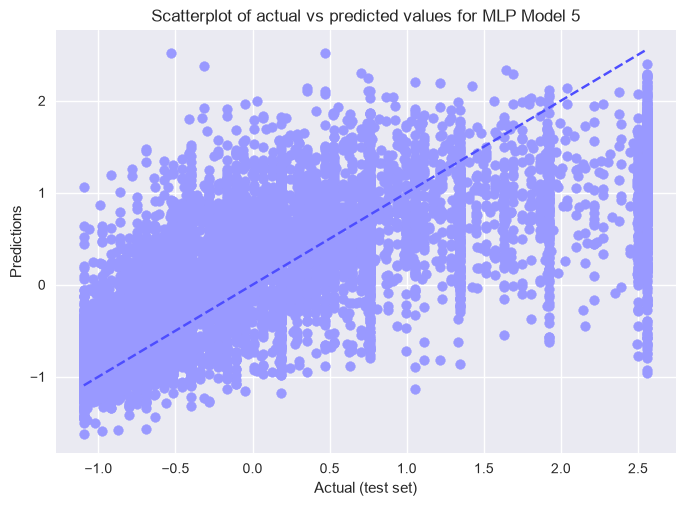

In [67]:
# plotting the scatter plot
plt.scatter(y_test_std, y_pred_MLP_Keras_5_test, color='#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle='--', c='#4d4dff')
# setting axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual vs predicted values for MLP Model 5')
plt.show();

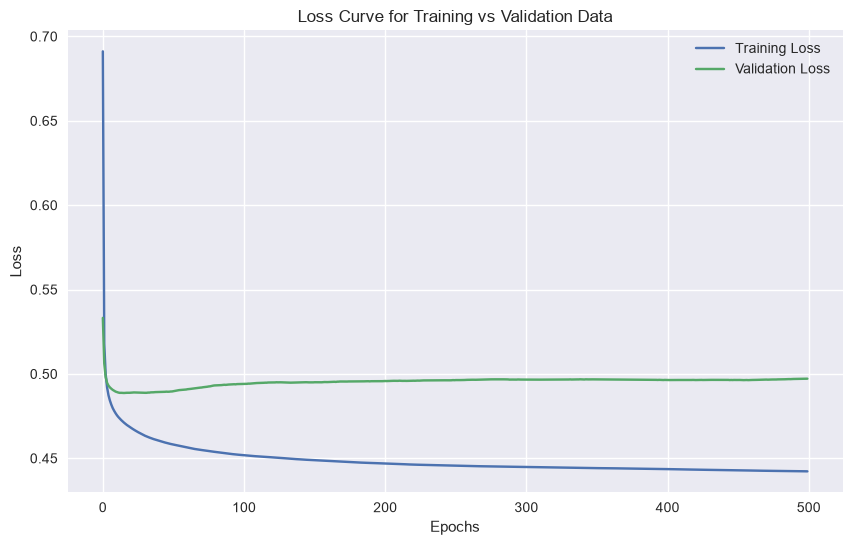

In [68]:
# Extracting loss values from the history object
train_loss_Keras5 = history_MLP_5_Keras.history['loss']
val_loss_Keras5 = history_MLP_5_Keras.history['val_loss']
# Setting up the plot
plt.figure(figsize = (10, 6))
plt.plot(train_loss_Keras5, label = 'Training Loss')
plt.plot(val_loss_Keras5, label = 'Validation Loss')
# Adding plot labels and title
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve for Training vs Validation Data')
plt.legend()
plt.show();

MLP_5 performance on unseen data was mediocre. Thus, next, MAE loss function was attempted, less sensitive to outliers which could be the issue with Airbnb's skewed data (Unpingco, 2016).

### 3.2.9. MLP_Model_6_Keras: MAE loss

In [69]:
# same model architecture
MLP_Model_6_Keras = keras.Sequential([
    keras.layers.Dense(units=64, input_dim=X_train_std.shape[1], activation='relu'),
    keras.layers.Dense(units=1)
])

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
# setting the random seed to ensure reproducibility of results
# setting the random seed for Numpy
np.random.seed(28)
# setting the random seed for Tensorflow
tf.random.set_seed(28)
#Compiling the model 
MLP_Model_6_Keras.compile(optimizer='adam',
                 #changing loss to MAE
                   loss='MAE',
                   metrics=['mean_squared_error', 'mean_absolute_error', coeff_determination])
# Timing the training process
start_time_MLP_6_keras = time.time()
# Train the model without early stopping and use the prepared validation set
history_MLP_6 = MLP_Model_6_Keras.fit(X_train_std, y_train_std, 
                         epochs=500, batch_size=128, 
                         validation_data=(X_val_std, y_val_std))
# End time
end_time_MLP_6_keras = time.time()

Epoch 1/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - coeff_determination: 0.3339 - loss: 0.5639 - mean_absolute_error: 0.5639 - mean_squared_error: 0.6634 - val_coeff_determination: 0.4568 - val_loss: 0.5078 - val_mean_absolute_error: 0.5078 - val_mean_squared_error: 0.5424
Epoch 2/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - coeff_determination: 0.4568 - loss: 0.4941 - mean_absolute_error: 0.4941 - mean_squared_error: 0.5411 - val_coeff_determination: 0.4762 - val_loss: 0.4924 - val_mean_absolute_error: 0.4924 - val_mean_squared_error: 0.5221
Epoch 3/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - coeff_determination: 0.4690 - loss: 0.4839 - mean_absolute_error: 0.4839 - mean_squared_error: 0.5291 - val_coeff_determination: 0.4830 - val_loss: 0.4867 - val_mean_absolute_error: 0.4867 - val_mean_squared_error: 0.5149
Epoch 4/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step - coeff_determination: 0.4753 - loss: 0.4791 - mean_absolute_error: 0.4791 - mean_squared_error: 0.5228 - val_

In [71]:
# Calculating the elapsed time
elapsed_time_MLP_6_keras = end_time_MLP_6_keras - start_time_MLP_6_keras
print(f'Elapsed time MLP 6: {elapsed_time_MLP_6_keras:.2f} seconds')

Elapsed time MLP 6: 83.13 seconds


In [72]:
# Making predictions on the training set
y_pred_MLP_Keras_6_train = MLP_Model_6_Keras.predict(X_train_std)
# Evaluating the model on the training set
train_loss_MLP_Keras_6, train_mse_MLP_Keras_6, train_mae_MLP_Keras_6, train_r2_MLP_Keras_6 = MLP_Model_6_Keras.evaluate(X_train_std, 
                                                                     y_train_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_6_train = train_loss_MLP_Keras_6
R2_MLP_Keras_6_train = train_r2_MLP_Keras_6
MSE_MLP_Keras_6_train = train_mse_MLP_Keras_6
MAE_MLP_Keras_6_train = train_mae_MLP_Keras_6
#Printing the metrics on the training set
print(f'The loss MLP Keras Model 6 on the training set:  {loss_MLP_Keras_6_train:.4f}')
print(f'The R-squared of the MLP Keras Model 6 on the training set: {R2_MLP_Keras_6_train:.4f}')
print(f'The MSE of the MLP Keras Model 6 on the training set: {MSE_MLP_Keras_6_train:.4f}')
print(f'MAE of the MLP Keras Model 6 on the training set: {MAE_MLP_Keras_6_train:.4f}')

978/978 ━━━━━━━━━━━━━━━━━━━━ 0s 212us/step
978/978 ━━━━━━━━━━━━━━━━━━━━ 0s 340us/step - coeff_determination: 0.5132 - loss: 0.4473 - mean_absolute_error: 0.4473 - mean_squared_error: 0.4703
The loss MLP Keras Model 6 on the training set:  0.4473
The R-squared of the MLP Keras Model 6 on the training set: 0.5132
The MSE of the MLP Keras Model 6 on the training set: 0.4703
MAE of the MLP Keras Model 6 on the training set: 0.4473


In [73]:
# Making predictions on the validation set
y_pred_MLP_Keras_6_val = MLP_Model_6_Keras.predict(X_val_std)
# Evaluating the performance of the model on the validation set
val_loss_MLP_Keras_6, val_mse_MLP_Keras_6, val_mae_MLP_Keras_6, val_r2_MLP_Keras_6 = MLP_Model_6_Keras.evaluate(X_val_std, 
                                                                     y_val_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_6_val = val_loss_MLP_Keras_6
R2_MLP_Keras_6_val = val_r2_MLP_Keras_6
MSE_MLP_Keras_6_val = val_mse_MLP_Keras_6
MAE_MLP_Keras_6_val = val_mae_MLP_Keras_6
#Printing the metrics on the validation set
print(f'The loss MLP Keras Model 6 on the validation set:  {loss_MLP_Keras_6_val:.4f}')
print(f'The R-squared of the MLP Keras Model 6 on the validation set:  {R2_MLP_Keras_6_val:.4f}')
print(f'The MSE of the MLP Keras Model 6 on the validation set:   {MSE_MLP_Keras_6_val:.4f}')
print(f'The MAE of the MLP Keras Model 6 on the validation set:  {MAE_MLP_Keras_6_val:.4f}')

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 222us/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 405us/step - coeff_determination: 0.4816 - loss: 0.4775 - mean_absolute_error: 0.4775 - mean_squared_error: 0.4994
The loss MLP Keras Model 6 on the validation set:  0.4775
The R-squared of the MLP Keras Model 6 on the validation set:  0.4816
The MSE of the MLP Keras Model 6 on the validation set:   0.4994
The MAE of the MLP Keras Model 6 on the validation set:  0.4775


In [74]:
# Making predictions on the test set
y_pred_MLP_Keras_6_test = MLP_Model_6_Keras.predict(X_test_std)
# Evaluating the performance on the test set
test_loss_MLP_Keras_6, test_mse_MLP_Keras_6, test_mae_MLP_Keras_6, test_r2_MLP_Keras_6 = MLP_Model_6_Keras.evaluate(X_test_std, 
                                                                     y_test_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_6_test = test_loss_MLP_Keras_6
R2_MLP_Keras_6_test = test_r2_MLP_Keras_6
MSE_MLP_Keras_6_test = test_mse_MLP_Keras_6
MAE_MLP_Keras_6_test = test_mae_MLP_Keras_6
#Printing the metrics on the test set
print(f'The loss MLP Keras Model 6 on the test set:  {loss_MLP_Keras_6_test:.4f}')
print(f'The R-squared of the MLP Keras Model 6 on the test set: {R2_MLP_Keras_6_test:.4f}')
print(f'The MSE of the MLP Keras Model 6 on the test set: {MSE_MLP_Keras_6_test:.4f}')
print(f'The MAE of the MLP Keras Model 6 on the test set: {MAE_MLP_Keras_6_test:.4f}')

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 215us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - coeff_determination: 0.4823 - loss: 0.4727 - mean_absolute_error: 0.4727 - mean_squared_error: 0.4961
The loss MLP Keras Model 6 on the test set:  0.4727
The R-squared of the MLP Keras Model 6 on the test set: 0.4823
The MSE of the MLP Keras Model 6 on the test set: 0.4961
The MAE of the MLP Keras Model 6 on the test set: 0.4727


#### Visualising

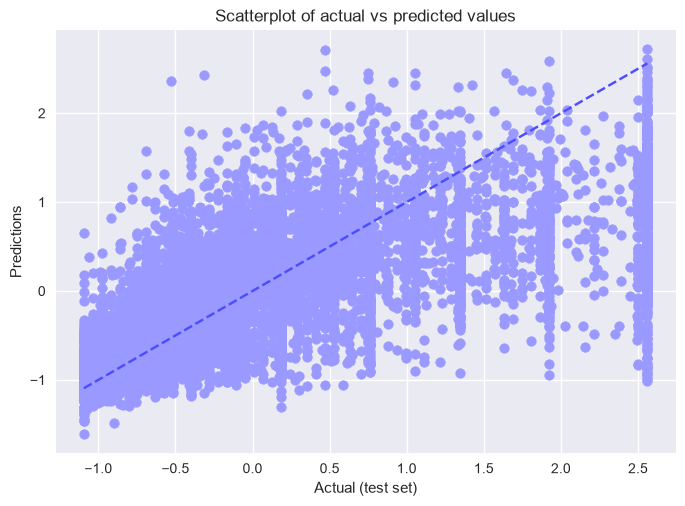

In [75]:
# plotting the scatter plot
plt.scatter(y_test_std, y_pred_MLP_Keras_6_test, color='#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()], 
         [y_test_std.min(), y_test_std.max()], linestyle='--', c='#4d4dff')
# Adding the axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual vs predicted values')
plt.show();

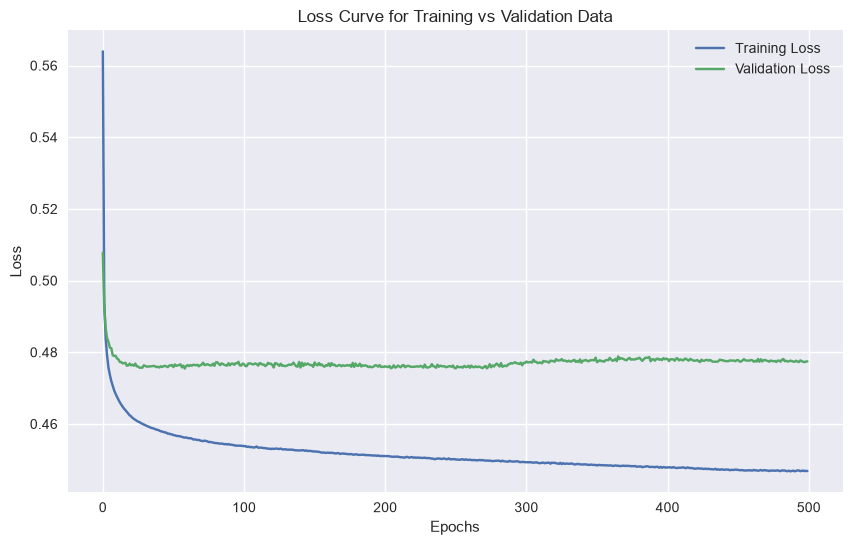

In [76]:
# Extracting loss values from the history object
train_loss_Keras_MLP_6 = history_MLP_6.history['loss']
val_loss_Keras_MLP_6 = history_MLP_6.history['val_loss']
# Setting up the plot
plt.figure(figsize=(10, 6))
plt.plot(train_loss_Keras_MLP_6, label='Training Loss')
plt.plot(val_loss_Keras_MLP_6, label='Validation Loss')
# Adding plot details
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve for Training vs Validation Data')
plt.legend()
plt.show();

MAE loss did not improve performace.Thus, MSE was kept for subsequent models

### 3.2.10. MLP_7: Changing Activation Function (->Elu)

Elu has a continuous minima(->smoothness), aiding the optimiser during backpropagation, leading to less chances of overshooting local minima during optimisation (Taud & Mass, 2018), and is suitable for price predictions.

In [77]:
# defining the simplified model architecture
MLP_Model_7_Keras = keras.Sequential([
    #1st fully-connected layer of the NN with 64 neurons, 
    #input shape=IVs and eLU (Exponential Linear Unit) activation function. 
    keras.layers.Dense(units=64, input_dim=X_train_std.shape[1], activation='elu'),
    keras.layers.Dense(units=1)
])

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
# setting the random seed to ensure reproducibility of results
# setting the random seed for Numpy
np.random.seed(28)
# setting the random seed for Tensorflow
tf.random.set_seed(28)
#Compiling the model 
MLP_Model_7_Keras.compile(optimizer='adam',
                   loss='MSE',
                   metrics=['mean_squared_error', 
                            'mean_absolute_error', coeff_determination])
# Timing the training process
start_time_MLP_7_keras =  time.time()
# Train the model without early stopping and use the prepared validation set
history_MLP_7_Keras = MLP_Model_7_Keras.fit(X_train_std, y_train_std, 
                         epochs=500, batch_size=128, 
                         validation_data=(X_val_std, y_val_std))
# End time
end_time_MLP_7_keras = time.time()

Epoch 1/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - coeff_determination: 0.4120 - loss: 0.5833 - mean_absolute_error: 0.5575 - mean_squared_error: 0.5833 - val_coeff_determination: 0.4562 - val_loss: 0.5381 - val_mean_absolute_error: 0.5408 - val_mean_squared_error: 0.5381
Epoch 2/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 670us/step - coeff_determination: 0.4633 - loss: 0.5327 - mean_absolute_error: 0.5298 - mean_squared_error: 0.5327 - val_coeff_determination: 0.4712 - val_loss: 0.5229 - val_mean_absolute_error: 0.5281 - val_mean_squared_error: 0.5229
Epoch 3/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 637us/step - coeff_determination: 0.4771 - loss: 0.5190 - mean_absolute_error: 0.5192 - mean_squared_error: 0.5190 - val_coeff_determination: 0.4811 - val_loss: 0.5129 - val_mean_absolute_error: 0.5195 - val_mean_squared_error: 0.5129
Epoch 4/500
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step - coeff_determination: 0.4866 - loss: 0.5096 - mean_absolute_error: 0.5117 - mean_squared_error: 0.5096 - val_

In [79]:
# Calculating the elapsed time
elapsed_time_MLP_7_keras = end_time_MLP_7_keras - start_time_MLP_7_keras
print(f'Elapsed time MLP 7: {elapsed_time_MLP_7_keras:.2f} seconds')

Elapsed time MLP 7: 88.77 seconds


In [80]:
# Making predictions on the training set
y_pred_MLP_Keras_7_train = MLP_Model_7_Keras.predict(X_train_std)
# Evaluating the model on the training set
train_loss_MLP_Keras_7, train_mse_MLP_Keras_7, train_mae_MLP_Keras_7, train_r2_MLP_Keras_7 = MLP_Model_7_Keras.evaluate(X_train_std, 
                                                                     y_train_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_7_train = train_loss_MLP_Keras_7
R2_MLP_Keras_7_train = train_r2_MLP_Keras_7
MSE_MLP_Keras_7_train = train_mse_MLP_Keras_7
MAE_MLP_Keras_7_train = train_mae_MLP_Keras_7
#Printing the metrics on the training set
print(f'The loss MLP Keras Model 7 on the training set:  {loss_MLP_Keras_7_train:.4f}')
print(f'The R-squared of the MLP Keras Model 7 on the training set: {R2_MLP_Keras_7_train:.4f}')
print(f'The MSE of the MLP Keras Model 7 on the training set: {MSE_MLP_Keras_7_train:.4f}')
print(f'MAE of the MLP Keras Model 7 on the training set: {MAE_MLP_Keras_7_train:.4f}')

978/978 ━━━━━━━━━━━━━━━━━━━━ 0s 273us/step
978/978 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - coeff_determination: 0.5316 - loss: 0.4435 - mean_absolute_error: 0.4771 - mean_squared_error: 0.4435
The loss MLP Keras Model 7 on the training set:  0.4435
The R-squared of the MLP Keras Model 7 on the training set: 0.5316
The MSE of the MLP Keras Model 7 on the training set: 0.4435
MAE of the MLP Keras Model 7 on the training set: 0.4771


In [81]:
#Making predictions on the validation set
y_pred_MLP_Keras_7_val = MLP_Model_7_Keras.predict(X_val_std)
# Evaluating the performance of the validation set
val_loss_MLP_Keras_7, val_mse_MLP_Keras_7, val_mae_MLP_Keras_7, val_r2_MLP_Keras_7 = MLP_Model_7_Keras.evaluate(X_val_std, 
                                                                     y_val_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_7_val = val_loss_MLP_Keras_7
R2_MLP_Keras_7_val = val_r2_MLP_Keras_7
MSE_MLP_Keras_7_val = val_mse_MLP_Keras_7
MAE_MLP_Keras_7_val = val_mae_MLP_Keras_7
#Printing the metrics on the validation set
print(f'The loss MLP Keras Model 7 on the validation set:  {loss_MLP_Keras_7_val:.4f}')
print(f'The R-squared of the MLP Keras Model 7 on the validation set:  {R2_MLP_Keras_7_val:.4f}')
print(f'The MSE of the MLP Keras Model 7 on the validation set:   {MSE_MLP_Keras_7_val:.4f}')
print(f'The MAE of the MLP Keras Model 7 on the validation set:  {MAE_MLP_Keras_7_val:.4f}')

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 240us/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step - coeff_determination: 0.4792 - loss: 0.4929 - mean_absolute_error: 0.5053 - mean_squared_error: 0.4929
The loss MLP Keras Model 7 on the validation set:  0.4929
The R-squared of the MLP Keras Model 7 on the validation set:  0.4792
The MSE of the MLP Keras Model 7 on the validation set:   0.4929
The MAE of the MLP Keras Model 7 on the validation set:  0.5053


In [82]:
#Making predictions on the test set
y_pred_MLP_Keras_7_test = MLP_Model_7_Keras.predict(X_test_std)
# Evaluating the performance on the test set
test_loss_MLP_Keras_7, test_mse_MLP_Keras_7, test_mae_MLP_Keras_7, test_r2_MLP_Keras_7 = MLP_Model_7_Keras.evaluate(X_test_std, 
                                                                     y_test_std)
#saving the results to the variables to, consequently, compare the models
loss_MLP_Keras_7_test = test_loss_MLP_Keras_7
R2_MLP_Keras_7_test = test_r2_MLP_Keras_7
MSE_MLP_Keras_7_test = test_mse_MLP_Keras_7
MAE_MLP_Keras_7_test = test_mae_MLP_Keras_7
#Printing the metrics on the test set
print(f'The loss MLP Keras Model 7 on the test set:  {loss_MLP_Keras_7_test:.4f}')
print(f'The R-squared of the MLP Keras Model 7 on the test set:  {R2_MLP_Keras_7_test:.4f}')
print(f'The MSE of the MLP Keras Model 7 on the test set:   {MSE_MLP_Keras_7_test:.4f}')
print(f'The MAE of the MLP Keras Model 7 on the test set:  {MAE_MLP_Keras_7_test:.4f}')

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 224us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 350us/step - coeff_determination: 0.4812 - loss: 0.4885 - mean_absolute_error: 0.4989 - mean_squared_error: 0.4885
The loss MLP Keras Model 7 on the test set:  0.4885
The R-squared of the MLP Keras Model 7 on the test set:  0.4812
The MSE of the MLP Keras Model 7 on the test set:   0.4885
The MAE of the MLP Keras Model 7 on the test set:  0.4989


#### Visualising

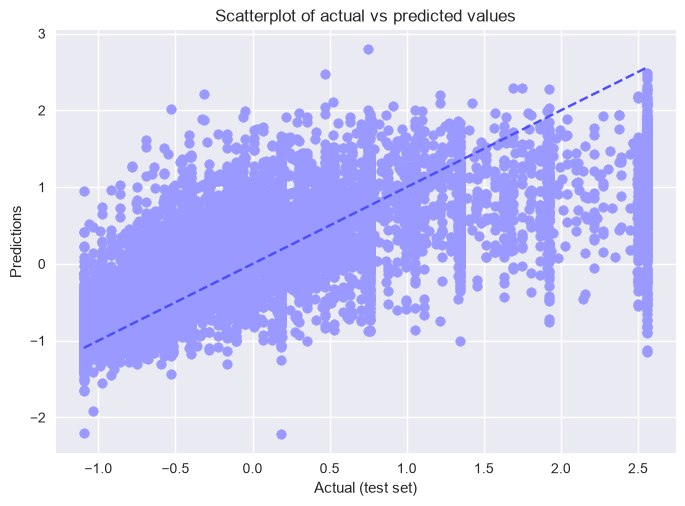

In [83]:
#plotting the scatter plot
plt.scatter(y_test_std, y_pred_MLP_Keras_7_test, color = '#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], linestyle = '--', c = '#4d4dff')
#adding the axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual vs predicted values')
plt.show();

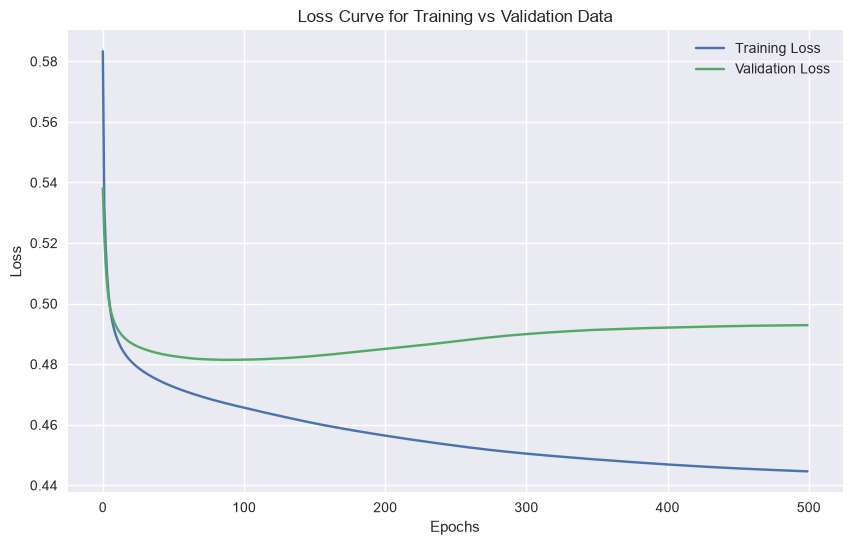

In [84]:
# Extracting loss values from the history object
train_loss_Keras_MLP_7 = history_MLP_7_Keras.history['loss']
val_loss_Keras_MLP_7 = history_MLP_7_Keras.history['val_loss']
# Setting up the plot
plt.figure(figsize=(10, 6))
plt.plot(train_loss_Keras_MLP_7, label='Training Loss')
plt.plot(val_loss_Keras_MLP_7, label='Validation Loss')
# Adding plot details
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve for Training vs Validation Data')
plt.legend()
plt.show();

Elu solely slightly improved model performance.While it is beneficial to address the vanishing gradient issue in deep networks,relu has the same possibility,especially when combimed with kernel_initializer='he_normal'. Thus, it was finally experimented whether making the network narroer and radically reducing epochs and batch_size would provide appropriate performance for Airbnb data.

### 3.2.11. MLP_Model_8 (Keras): Radical Hyparameter Change

In [85]:
# defining the model architecture
MLP_Model_Keras_8 = keras.Sequential([
    #relu activation function and he_normal initialiser
    keras.layers.Dense(units=16, input_dim=X_train_std.shape[1], activation='relu'),
    keras.layers.Dense(units=8, activation='relu',  kernel_initializer='he_normal'),
    keras.layers.Dense(units=1)
])

/Users/varia/.conda/envs/airbnb-text/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
MLP_Model_Keras_8.compile(optimizer='adam', loss='MSE', 
                   metrics=['mse', 'mae', coeff_determination])
start_time_Keras_8 =  time.time()
history_MLP_8 = MLP_Model_Keras_8.fit(X_train_std, y_train_std, 
                                              epochs=50, batch_size=32, 
                                              validation_data=(X_val_std, y_val_std),
                                              verbose=0)
#end time
end_time_Keras_8 = time.time()

In [87]:
#calculating the training time
elapsed_time_Keras_8 = end_time_Keras_8 - start_time_Keras_8
print(f"Elapsed time: {elapsed_time_Keras_8:.2f} seconds")

Elapsed time: 26.99 seconds


In [88]:
# Making predictions on the training set
y_pred_MLP_Keras_8_train = MLP_Model_Keras_8.predict(X_train_std)
# Evaluating the model on the training set
#utilising the evaluate() method is a method, specific to the Keras API
#for Neural Networks
train_loss_MLP_Keras_8, train_mse_MLP_Keras_8, train_mae_MLP_Keras_8, train_r2_MLP_Keras_8 = MLP_Model_Keras_8.evaluate(X_train_std, 
                                                                     y_train_std)
#saving the results to the variables
loss_MLP_Keras_8_train = train_loss_MLP_Keras_8
R2_MLP_Keras_8_train = train_r2_MLP_Keras_8
MSE_MLP_Keras_8_train = train_mse_MLP_Keras_8
MAE_MLP_Keras_8_train = train_mae_MLP_Keras_8
#Printing the metrics on the training set
print(f'The loss MLP Keras Model 8 on the training set:  {loss_MLP_Keras_8_train:.4f}')
print(f'The R-squared of the MLP Keras Model 8 on the training set: {R2_MLP_Keras_8_train:.4f}')
print(f'The MSE of the MLP Keras Model 8 on the training set: {MSE_MLP_Keras_8_train:.4f}')
print(f'MAE of the MLP Keras Model 8 on the training set: {MAE_MLP_Keras_8_train:.4f}')

978/978 ━━━━━━━━━━━━━━━━━━━━ 0s 228us/step
978/978 ━━━━━━━━━━━━━━━━━━━━ 0s 415us/step - coeff_determination: 0.5137 - loss: 0.4612 - mae: 0.4791 - mse: 0.4612
The loss MLP Keras Model 8 on the training set:  0.4612
The R-squared of the MLP Keras Model 8 on the training set: 0.5137
The MSE of the MLP Keras Model 8 on the training set: 0.4612
MAE of the MLP Keras Model 8 on the training set: 0.4791


In [89]:
#Making predictions on the validation set
y_pred_MLP_Keras_8_val = MLP_Model_Keras_8.predict(X_val_std)
# Evaluating the performance of the validation set
val_loss_MLP_Keras_8, val_mse_MLP_Keras_8, val_mae_MLP_Keras_8, val_r2_MLP_Keras_8 = MLP_Model_Keras_8.evaluate(X_val_std, 
                                                                     y_val_std)
#saving the results to the variables
loss_MLP_Keras_8_val = val_loss_MLP_Keras_8
R2_MLP_Keras_8_val = val_r2_MLP_Keras_8
MSE_MLP_Keras_8_val = val_mse_MLP_Keras_8
MAE_MLP_Keras_8_val = val_mae_MLP_Keras_8
#Printing the metrics on the validation set
print(f'The loss MLP Keras Model 8 on the validation set:  {loss_MLP_Keras_8_val:.4f}')
print(f'The R-squared of the MLP Keras Model 8 on the validation set:  {R2_MLP_Keras_8_val:.4f}')
print(f'The MSE of the MLP Keras Model 8 on the validation set:   {MSE_MLP_Keras_8_val:.4f}')
print(f'The MAE of the MLP Keras Model 8 on the validation set:  {MAE_MLP_Keras_8_val:.4f}')

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 413us/step
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - coeff_determination: 0.4974 - loss: 0.4766 - mae: 0.4912 - mse: 0.4766
The loss MLP Keras Model 8 on the validation set:  0.4766
The R-squared of the MLP Keras Model 8 on the validation set:  0.4974
The MSE of the MLP Keras Model 8 on the validation set:   0.4766
The MAE of the MLP Keras Model 8 on the validation set:  0.4912


In [90]:
#predcting on the test set 
y_pred_MLP_Keras_8_test = MLP_Model_Keras_8.predict(X_test_std)
# Evaluating the performance 
test_loss_MLP_Keras_8, test_mse_MLP_Keras_8, test_mae_MLP_Keras_8, test_r2_MLP_Keras_8 = MLP_Model_Keras_8.evaluate(X_test_std, 
                                                                     y_test_std)
#saving the results to the variables to, 
#consequently, compare the models
loss_MLP_Keras_8_test = test_loss_MLP_Keras_8
R2_MLP_Keras_8_test = test_r2_MLP_Keras_8
MSE_MLP_Keras_8_test = test_mse_MLP_Keras_8
MAE_MLP_Keras_8_test = test_mae_MLP_Keras_8
#Printing the metrics on the test set
print(f'The loss MLP Keras Model 8 on the test set:  {loss_MLP_Keras_8_test:.4f}')
print(f'The R-squared of the MLP Keras Model 8 on the test set:  {R2_MLP_Keras_8_test:.4f}')
print(f'The MSE of the MLP Keras Model 8 on the test set:   {MSE_MLP_Keras_8_test:.4f}')
print(f'The MAE of the MLP Keras Model 8 on the test set:  {MAE_MLP_Keras_8_test:.4f}')

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 387us/step - coeff_determination: 0.4956 - loss: 0.4732 - mae: 0.4855 - mse: 0.4732
The loss MLP Keras Model 8 on the test set:  0.4732
The R-squared of the MLP Keras Model 8 on the test set:  0.4956
The MSE of the MLP Keras Model 8 on the test set:   0.4732
The MAE of the MLP Keras Model 8 on the test set:  0.4855


#### Visualising

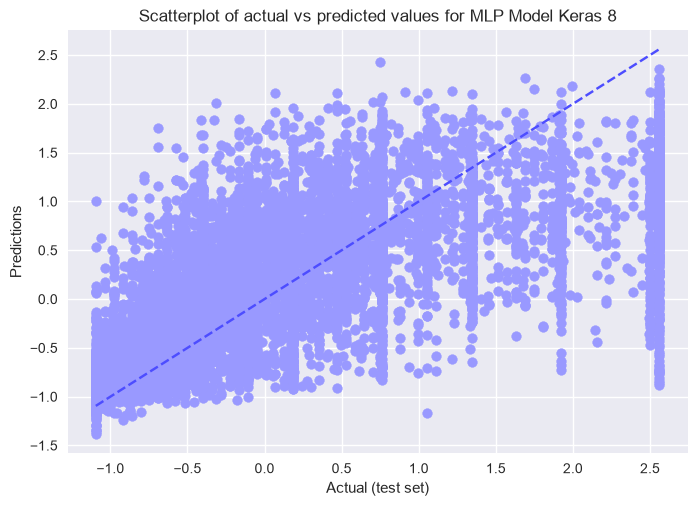

In [91]:
# plotting the scatter plot
plt.scatter(y_test_std, y_pred_MLP_Keras_8_test, color = '#9999ff')
# Adding a diagonal line for reference
plt.plot([y_test_std.min(), y_test_std.max()],
         [y_test_std.min(), y_test_std.max()], 
         linestyle = '--', c = '#4d4dff')
# adding the axes labels and title
plt.xlabel('Actual (test set)')
plt.ylabel('Predictions')
plt.title('Scatterplot of actual vs predicted values for MLP Model Keras 8')
plt.show();

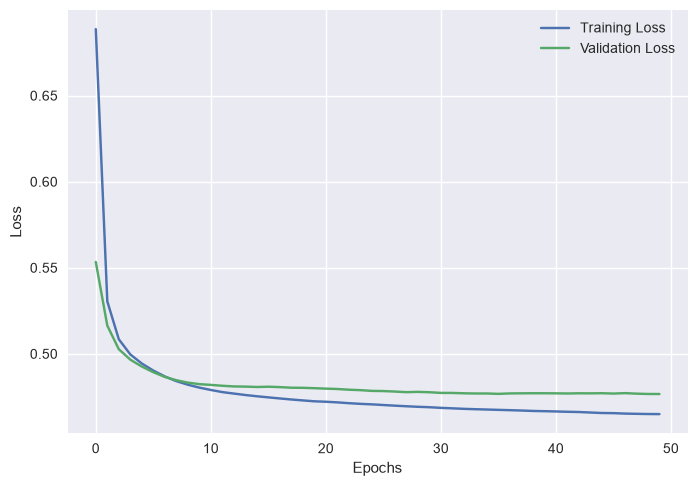

In [92]:
# Plotting the training and validation loss curves
plt.plot(history_MLP_8.history['loss'], label='Training Loss')
plt.plot(history_MLP_8.history['val_loss'], label='Validation Loss')
# Adding labels and legends
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

## 3.3. Evaluating Models’ Performance

In [93]:
# Model performance: Iteration 1
#Ridge_1
print(f'R2 Ridge_1: {R2_Ridge_1_test * 100:.2f}%')
print(f'MSE Ridge_1: {MSE_Ridge_1_test:.2f}')
print(f'MAE Ridge_1: {MAE_Ridge_1_test:.2f}')
print(f'Training time Ridge_1: {training_time_Ridge_1/60:.4f} minutes\n')
#RF_1
print(f'R2 RF_1: {R2_RF_1_test* 100:.2f}%')
print(f'MSE RF_1: {MSE_RF_1_test:.2f}')
print(f'MAE RF_1:  {MAE_RF_1_test:.2f}')
print(f'Training time RF_1: {training_time_RF_1/60:.4f} minutes\n')
#XGB_1
print(f'R2 XGB_1: {R2_XGB_1_test * 100:.2f}%')
print(f'MSE XGB_1: {MSE_XGB_1_test:.2f}')
print(f'MAE XGB_1: {MAE_XGB_1_test:.2f}')
print(f'Training time XGB_1: {training_time_XGB_1/60:.4f} minutes\n')

R2 Ridge_1: 46.57%
MSE Ridge_1: 0.53
MAE Ridge_1: 0.53
Training time Ridge_1: 0.0006 minutes

R2 RF_1: 54.67%
MSE RF_1: 0.45
MAE RF_1:  0.48
Training time RF_1: 0.4238 minutes

R2 XGB_1: 54.06%
MSE XGB_1: 0.46
MAE XGB_1: 0.48
Training time XGB_1: 0.0057 minutes



In [94]:
#MLP 1
print(f'R2 MLP_1: {R2_MLP_basic_1_test * 100:.2f}%')
print(f'MSE MLP_1: {MSE_MLP_basic_1_test:.2f}')
print(f'MAE MLP_1: {MAE_MLP_basic_1_test:.2f}')
print(f'Training time MLP 1: {training_time_MLP_basic_1/60:.2f} minutes\n')
#MLP 2
print(f'R2 MLP_2: {R2_MLP_2_test * 100:.2f}%')
print(f'MSE MLP_2: {MSE_MLP_2_test:.2f}')
print(f'MAE MLP_2: {MAE_MLP_2_test:.2f}')
print(f'Training time MLP 2: {training_time_MLP_2/60:.2f} minutes\n')
#MLP 3
print(f'R2 MLP_3: {R2_MLP_3_test * 100:.2f}%')
print(f'MSE MLP_3: {MSE_MLP_3_test:.2f}')
print(f'MAE MLP_3: {MAE_MLP_3_test:.2f}')
print(f'Training time MLP 3: {training_time_MLP_3/60:.2f} minutes\n')
#MLP 4
print(f'R2 MLP_4: {R2_MLP_4_test * 100:.2f}%')
print(f'MSE MLP_4: {MSE_MLP_4_test:.2f}')
print(f'MAE MLP_4: {MAE_MLP_4_test:.2f}')
print(f'Training time MLP_4: {training_time_MLP_4/60:.2f} minutes\n')
#MLP 5 Keras 
print(f'R2 MLP_5_Keras: {R2_MLP_Keras_5_test * 100:.2f}%')
print(f'MSE MLP_5_Keras: {MSE_MLP_Keras_5_test :.2f}')
print(f'MAE MLP_5_Keras: {MAE_MLP_Keras_5_test :.2f}')
print(f'Training time MLP_5_Keras: {elapsed_time_MLP_5_keras/60:.2f} minutes\n')
#MLP 6 Keras 
print(f'R2 MLP_6_Keras: {R2_MLP_Keras_6_test * 100:.2f}%')
print(f'MSE MLP_6_Keras: {MSE_MLP_Keras_6_test :.2f}')
print(f'MAE MLP_6_Keras: {MAE_MLP_Keras_6_test :.2f}')
print(f'Training time MLP_6_Keras: {elapsed_time_MLP_6_keras/60:.2f} minutes\n')
#MLP 7 Keras 
print(f'R2 MLP_7_Keras: {R2_MLP_Keras_7_test * 100:.2f}%')
print(f'MSE MLP_7_Keras: {MSE_MLP_Keras_7_test :.2f}')
print(f'MAE MLP_7_Keras: {MAE_MLP_Keras_7_test :.2f}')
print(f'Training time MLP_7_Keras: {elapsed_time_MLP_7_keras/60:.2f} minutes\n')
#MLP 8 Keras 
print(f'R2 MLP_8_Keras: {R2_MLP_Keras_8_test * 100:.2f}%')
print(f'MSE MLP_8_Keras: {MSE_MLP_Keras_8_test :.2f}')
print(f'MAE MLP_8_Keras: {MAE_MLP_Keras_8_test :.2f}')
print(f'Training time MLP_8_Keras: {elapsed_time_Keras_8/60:.2f} minutes')

R2 MLP_1: 50.02%
MSE MLP_1: 0.50
MAE MLP_1: 0.51
Training time MLP 1: 0.11 minutes

R2 MLP_2: 33.96%
MSE MLP_2: 0.66
MAE MLP_2: 0.58
Training time MLP 2: 0.32 minutes

R2 MLP_3: 51.12%
MSE MLP_3: 0.49
MAE MLP_3: 0.50
Training time MLP 3: 0.29 minutes

R2 MLP_4: 34.83%
MSE MLP_4: 0.65
MAE MLP_4: 0.57
Training time MLP_4: 0.32 minutes

R2 MLP_5_Keras: 47.88%
MSE MLP_5_Keras: 0.49
MAE MLP_5_Keras: 0.50
Training time MLP_5_Keras: 1.40 minutes

R2 MLP_6_Keras: 48.23%
MSE MLP_6_Keras: 0.50
MAE MLP_6_Keras: 0.47
Training time MLP_6_Keras: 1.39 minutes

R2 MLP_7_Keras: 48.12%
MSE MLP_7_Keras: 0.49
MAE MLP_7_Keras: 0.50
Training time MLP_7_Keras: 1.48 minutes

R2 MLP_8_Keras: 49.56%
MSE MLP_8_Keras: 0.47
MAE MLP_8_Keras: 0.49
Training time MLP_8_Keras: 0.45 minutes


Overall, RF_1 and XGB_1 performed best (R² of 54.7% and 54.1%, respectively), while Ridge (the simplest model) performed similarly to the initial Neural Networks (R² of 46.6%, against 34–51% for the MLPs). Thus, the first 3 models will be further evaluated with grid search and 5-fold cross-validation. For MLPs, the simplest model (Model_8), with 2 narrow layers and a minimum number of epochs, performed slightly worse than Model_1 (R² of 49.5% vs 50.0%), which was among the best-performing MLPs. While Model_8 was not superior, it has significant improvement potential. Thus, Model_8 and Model_1 were kept for the subsequent analysis, with ReLU activation, MSE loss and the 'adam' optimiser, providing an optimal balance between simplicity, speed and model performance.

When using cv, the overfitting risk is reduced. However, upon too many hyperparameters in the grid search, a model that performs well on cv, yet, 
has a poor generalisation to test data can be selected. Thus, CONSTRAINING THE HYPERPARAMETER SEARCH SPACE  to mitigate this issue, selecting solely the hyperparameters considered the most important and limiting the possible values' range.